# Oligopoly Pricing in Finance: A Duopoly Comparison of Cournot and Bertrand Competition
### A Simulation-Based Study in Economics, Game Theory & Finance

---

## What is this project?

This notebook models **duopoly competition** — a market with exactly two competing firms —
using two classical game-theory frameworks:

| Model | Firms compete on... | Key Insight |
|---|---|---|
| **Cournot** | Quantities | Firms share the market; prices stay above cost |
| **Bertrand** | Prices | Undercutting drives price → marginal cost |

### Why does this matter in Finance?
- Two **banks** competing on loan/deposit rates → Bertrand logic
- Two **brokers** competing on trading fees → fee wars, margin compression
- Two **fintechs** setting prices against an incumbent → cost advantage matters
- **Underwriters/lenders** controlling volume supplied → Cournot logic

### What will we build?
1. Analytical + numerical Cournot equilibrium
2. Analytical + numerical Bertrand equilibrium
3. Side-by-side comparison of prices, quantities, profits
4. Sensitivity analysis (varying costs, demand)
5. Asymmetric firms (one firm more efficient)
6. Professional visualizations
7. Welfare analysis (bonus)

> All theory is self-contained — no external dataset required.

In [ ]:
# ============================================================
# SECTION 1: IMPORTS
# ============================================================
# Standard scientific stack — all available in Google Colab by default

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sympy import symbols, solve, diff, simplify, Rational, latex, pprint
import itertools
import warnings

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.figsize'  : (10, 5),
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 12,
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
    'legend.fontsize' : 11,
})

sns.set_palette("tab10")

print("✅ All libraries imported successfully.")
print(f"   numpy   {np.__version__}")
print(f"   pandas  {pd.__version__}")
print(f"   sympy   imported")
print(f"   seaborn {sns.__version__}")

✅ All libraries imported successfully.
   numpy   2.0.2
   pandas  2.2.2
   sympy   imported
   seaborn 0.13.2


In [ ]:
# ============================================================
# SECTION 2: BASELINE PARAMETERS
# ============================================================
# Change ONLY this block to re-run the entire notebook with
# different market conditions.

# ── Demand: inverse demand P = a - b*Q ──────────────────────
a = 100      # demand intercept  (higher → bigger market)
b = 1        # demand slope      (higher → steeper demand curve)

# ── Costs: C_i(q_i) = c_i * q_i  (linear, no fixed cost) ───
c1 = 20      # marginal cost of Firm 1
c2 = 20      # marginal cost of Firm 2  (set c1 ≠ c2 for asymmetric case)

# ── Display current setup ───────────────────────────────────
params = {
    'Parameter'  : ['a (demand intercept)',
                     'b (demand slope)',
                     'c1 (MC Firm 1)',
                     'c2 (MC Firm 2)'],
    'Value'      : [a, b, c1, c2],
    'Interpretation': [
        'Max willingness to pay = 100',
        'Price falls by 1 for each unit of total output',
        'Firm 1 produces each unit for cost 20',
        'Firm 2 produces each unit for cost 20'
    ]
}

df_params = pd.DataFrame(params)
print("=" * 60)
print("  BASELINE MODEL PARAMETERS")
print("=" * 60)
print(df_params.to_string(index=False))
print()
print(f"  Inverse demand:  P = {a} - {b}·Q")
print(f"  Cost Firm 1:     C₁ = {c1}·q₁")
print(f"  Cost Firm 2:     C₂ = {c2}·q₂")
print("=" * 60)

  BASELINE MODEL PARAMETERS
           Parameter  Value                                 Interpretation
a (demand intercept)    100                   Max willingness to pay = 100
    b (demand slope)      1 Price falls by 1 for each unit of total output
      c1 (MC Firm 1)     20          Firm 1 produces each unit for cost 20
      c2 (MC Firm 2)     20          Firm 2 produces each unit for cost 20

  Inverse demand:  P = 100 - 1·Q
  Cost Firm 1:     C₁ = 20·q₁
  Cost Firm 2:     C₂ = 20·q₂


In [ ]:
# ============================================================
# SECTION 3A: COURNOT — SYMBOLIC DERIVATION (SymPy)
# ============================================================

# ── Define symbolic variables ────────────────────────────────
q1, q2 = symbols('q1 q2', positive=True)
a_s, b_s, c1_s, c2_s = symbols('a b c1 c2', positive=True)

# ── Inverse demand (symbolic) ────────────────────────────────
P_sym = a_s - b_s * (q1 + q2)

# ── Profit functions ─────────────────────────────────────────
pi1 = (P_sym - c1_s) * q1      # Firm 1 profit
pi2 = (P_sym - c2_s) * q2      # Firm 2 profit

print("=" * 55)
print("  PROFIT FUNCTIONS")
print("=" * 55)
print(f"\n  π₁ = {pi1}")
print(f"\n  π₂ = {pi2}")

# ── First-order conditions: dπ/dq = 0 ───────────────────────
foc1 = diff(pi1, q1)     # ∂π₁/∂q₁
foc2 = diff(pi2, q2)     # ∂π₂/∂q₂

print("\n" + "=" * 55)
print("  FIRST-ORDER CONDITIONS  (set = 0)")
print("=" * 55)
print(f"\n  ∂π₁/∂q₁ = {foc1}  = 0")
print(f"\n  ∂π₂/∂q₂ = {foc2}  = 0")

# ── Best Response Functions ──────────────────────────────────
# Solve FOC for each firm's own quantity (taking rival's as given)
BR1 = solve(foc1, q1)[0]    # q1* as function of q2
BR2 = solve(foc2, q2)[0]    # q2* as function of q1

print("\n" + "=" * 55)
print("  BEST RESPONSE FUNCTIONS")
print("=" * 55)
print(f"\n  BR₁(q2) = {BR1}")
print(f"\n  BR₂(q1) = {BR2}")

# ── Nash Equilibrium: solve BR system simultaneously ─────────
eq_solution = solve([foc1, foc2], [q1, q2])
q1_star_sym = simplify(eq_solution[q1])
q2_star_sym = simplify(eq_solution[q2])

# ── Derived equilibrium quantities ──────────────────────────
Q_star_sym  = simplify(q1_star_sym + q2_star_sym)
P_star_sym  = simplify(a_s - b_s * Q_star_sym)
pi1_star_sym = simplify(pi1.subs([(q1, q1_star_sym), (q2, q2_star_sym)]))
pi2_star_sym = simplify(pi2.subs([(q1, q1_star_sym), (q2, q2_star_sym)]))

print("\n" + "=" * 55)
print("  COURNOT-NASH EQUILIBRIUM  (general symbolic)")
print("=" * 55)
print(f"\n  q1* = {q1_star_sym}")
print(f"\n  q2* = {q2_star_sym}")
print(f"\n  Q*  = {Q_star_sym}")
print(f"\n  P*  = {P_star_sym}")
print(f"\n  π₁* = {pi1_star_sym}")
print(f"\n  π₂* = {pi2_star_sym}")

  PROFIT FUNCTIONS

  π₁ = q1*(a - b*(q1 + q2) - c1)

  π₂ = q2*(a - b*(q1 + q2) - c2)

  FIRST-ORDER CONDITIONS  (set = 0)

  ∂π₁/∂q₁ = a - b*q1 - b*(q1 + q2) - c1  = 0

  ∂π₂/∂q₂ = a - b*q2 - b*(q1 + q2) - c2  = 0

  BEST RESPONSE FUNCTIONS

  BR₁(q2) = (a - b*q2 - c1)/(2*b)

  BR₂(q1) = (a - b*q1 - c2)/(2*b)

  COURNOT-NASH EQUILIBRIUM  (general symbolic)

  q1* = (a - 2*c1 + c2)/(3*b)

  q2* = (a + c1 - 2*c2)/(3*b)

  Q*  = (2*a - c1 - c2)/(3*b)

  P*  = a/3 + c1/3 + c2/3

  π₁* = (-a + 2*c1 - c2)**2/(9*b)

  π₂* = (-a - c1 + 2*c2)**2/(9*b)


In [ ]:
# ============================================================
# SECTION 3B: COURNOT — NUMERICAL SOLUTION
# ============================================================

def cournot_equilibrium(a, b, c1, c2):
    """
    Solve for Cournot-Nash equilibrium analytically.

    Formula derivation:
        q1* = (a - 2c1 + c2) / (3b)
        q2* = (a - 2c2 + c1) / (3b)

    Parameters
    ----------
    a  : demand intercept
    b  : demand slope
    c1 : marginal cost firm 1
    c2 : marginal cost firm 2

    Returns
    -------
    dict with all equilibrium values
    """
    q1_eq = (a - 2*c1 + c2) / (3*b)
    q2_eq = (a - 2*c2 + c1) / (3*b)
    Q_eq  = q1_eq + q2_eq
    P_eq  = a - b * Q_eq
    pi1_eq = (P_eq - c1) * q1_eq
    pi2_eq = (P_eq - c2) * q2_eq

    return {
        'q1_star'    : q1_eq,
        'q2_star'    : q2_eq,
        'Q_star'     : Q_eq,
        'P_star'     : P_eq,
        'profit1'    : pi1_eq,
        'profit2'    : pi2_eq,
        'total_profit': pi1_eq + pi2_eq
    }


def best_response_1(q2_val, a, b, c1):
    """Firm 1's best response given q2."""
    return max(0, (a - c1 - b * q2_val) / (2 * b))

def best_response_2(q1_val, a, b, c2):
    """Firm 2's best response given q1."""
    return max(0, (a - c2 - b * q1_val) / (2 * b))


# ── Compute with baseline parameters ────────────────────────
cournot = cournot_equilibrium(a, b, c1, c2)

# ── Display results ──────────────────────────────────────────
print("=" * 50)
print("  COURNOT EQUILIBRIUM RESULTS")
print(f"  (a={a}, b={b}, c1={c1}, c2={c2})")
print("=" * 50)

results_df = pd.DataFrame({
    'Variable'     : ['q1*', 'q2*', 'Q* (total)', 'P* (price)',
                      'π₁* (profit F1)', 'π₂* (profit F2)', 'Total Profit'],
    'Value'        : [round(v, 4) for v in cournot.values()],
    'Interpretation': [
        'Firm 1 optimal quantity',
        'Firm 2 optimal quantity',
        'Total market output',
        'Resulting market price',
        'Firm 1 equilibrium profit',
        'Firm 2 equilibrium profit',
        'Combined industry profit'
    ]
})

print(results_df.to_string(index=False))

print(f"""
Key checks:
  • Both firms produce same quantity (c1=c2): {round(cournot['q1_star'],2) == round(cournot['q2_star'],2)}
  • Price > marginal cost:  {round(cournot['P_star'],2)} > {c1}  ✓
  • Each firm earns positive profit:  π₁={round(cournot['profit1'],2)}, π₂={round(cournot['profit2'],2)}  ✓
""")

  COURNOT EQUILIBRIUM RESULTS
  (a=100, b=1, c1=20, c2=20)
       Variable     Value            Interpretation
            q1*   26.6667   Firm 1 optimal quantity
            q2*   26.6667   Firm 2 optimal quantity
     Q* (total)   53.3333       Total market output
     P* (price)   46.6667    Resulting market price
π₁* (profit F1)  711.1111 Firm 1 equilibrium profit
π₂* (profit F2)  711.1111 Firm 2 equilibrium profit
   Total Profit 1422.2222  Combined industry profit

Key checks:
  • Both firms produce same quantity (c1=c2): True
  • Price > marginal cost:  46.67 > 20  ✓
  • Each firm earns positive profit:  π₁=711.11, π₂=711.11  ✓



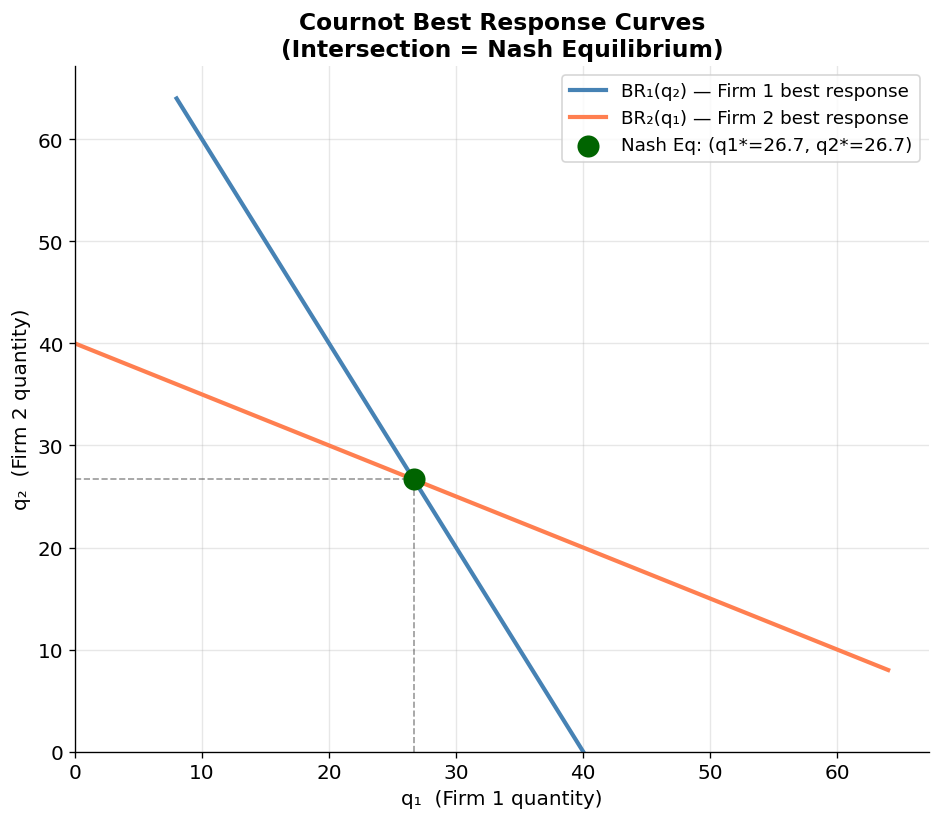

  ↑ The green dot is the only point where BOTH firms are simultaneously
    on their best response curve — neither wants to deviate unilaterally.


In [ ]:
# ============================================================
# SECTION 3C: BEST RESPONSE CURVES — VISUALISATION
# ============================================================

def plot_best_responses(a, b, c1, c2, cournot_eq):
    """
    Plot Firm 1 and Firm 2 best response curves.
    Their intersection = Cournot-Nash equilibrium.
    """
    q_max = (a - min(c1, c2)) / b   # theoretical max output for one firm

    q_range = np.linspace(0, q_max * 0.8, 300)

    br1_vals = [best_response_1(q, a, b, c1) for q in q_range]  # q1 given q2
    br2_vals = [best_response_2(q, a, b, c2) for q in q_range]  # q2 given q1

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.plot(br1_vals, q_range,
            label='BR₁(q₂) — Firm 1 best response',
            color='steelblue', linewidth=2.5)

    # BR2 gives q2 as function of q1 → plot q1 on x-axis, q2 on y-axis
    ax.plot(q_range, br2_vals,
            label='BR₂(q₁) — Firm 2 best response',
            color='coral', linewidth=2.5)

    # Nash equilibrium point
    ax.scatter(cournot_eq['q1_star'], cournot_eq['q2_star'],
               s=150, zorder=5, color='darkgreen',
               label=f"Nash Eq: (q1*={cournot_eq['q1_star']:.1f}, q2*={cournot_eq['q2_star']:.1f})")

    # Dotted lines to axes
    ax.plot([cournot_eq['q1_star'], cournot_eq['q1_star']],
            [0, cournot_eq['q2_star']], 'k--', alpha=0.4, linewidth=1)
    ax.plot([0, cournot_eq['q1_star']],
            [cournot_eq['q2_star'], cournot_eq['q2_star']], 'k--', alpha=0.4, linewidth=1)

    ax.set_xlabel('q₁  (Firm 1 quantity)')
    ax.set_ylabel('q₂  (Firm 2 quantity)')
    ax.set_title('Cournot Best Response Curves\n(Intersection = Nash Equilibrium)',
                 fontweight='bold')
    ax.legend()
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()
    print("  ↑ The green dot is the only point where BOTH firms are simultaneously")
    print("    on their best response curve — neither wants to deviate unilaterally.")

plot_best_responses(a, b, c1, c2, cournot)

---
## Section 4: Bertrand Competition Model

### Core Idea
Each firm **simultaneously sets a price**.
Consumers are rational and always buy from the **cheaper firm**.

### The Undercutting Logic
- If Firm 1 sets p1 > c, Firm 2 can set p2 = p1 - ε and steal the entire market
- Firm 1 then undercuts back → prices race to the bottom
- This continues until **p = marginal cost** — zero economic profit

### Demand Allocation Rule
| Condition | Firm 1 demand | Firm 2 demand |
|---|---|---|
| p1 < p2 | Full market: Q = a - b·p1 | 0 |
| p2 < p1 | 0 | Full market: Q = a - b·p2 |
| p1 = p2 | Half market | Half market |

### Bertrand Paradox
With **identical products and identical costs**, two firms are enough
to replicate the perfectly competitive outcome (P = MC).
This is called the **Bertrand Paradox**.

In [ ]:
# ============================================================
# SECTION 4A: BERTRAND — PROFIT FUNCTIONS & EQUILIBRIUM
# ============================================================

def market_demand(price, a, b):
    """
    Market demand at a given price.
    Q = a - b*p  (standard linear demand)
    Returns 0 if price exceeds max willingness to pay.
    """
    return max(0, a - b * price)


def bertrand_profits(p1, p2, a, b, c1, c2):
    """
    Compute Firm 1 and Firm 2 profits under Bertrand competition.

    Rules:
    - Cheaper firm captures entire market
    - Equal prices → market split 50/50
    - Profit = (price - marginal cost) * quantity sold

    Parameters
    ----------
    p1, p2 : prices set by Firm 1 and Firm 2
    a, b   : demand parameters
    c1, c2 : marginal costs

    Returns
    -------
    (profit1, profit2) tuple
    """
    if p1 < p2:
        # Firm 1 wins entire market
        q1 = market_demand(p1, a, b)
        q2 = 0
    elif p2 < p1:
        # Firm 2 wins entire market
        q1 = 0
        q2 = market_demand(p2, a, b)
    else:
        # Tied price → split equally
        q_total = market_demand(p1, a, b)
        q1 = q_total / 2
        q2 = q_total / 2

    profit1 = (p1 - c1) * q1
    profit2 = (p2 - c2) * q2

    return profit1, profit2


def bertrand_equilibrium(a, b, c1, c2):
    """
    Compute the Bertrand-Nash equilibrium analytically.

    With homogeneous goods:
    - If c1 == c2: both price at MC, zero profit
    - If c1 != c2: efficient firm prices just below rival's MC,
      captures full market, earns small positive profit

    Returns
    -------
    dict with equilibrium values
    """
    if abs(c1 - c2) < 1e-9:
        # Symmetric case: Bertrand paradox → P = MC
        p_eq   = c1                         # price = marginal cost
        Q_eq   = market_demand(p_eq, a, b)  # quantity at MC price
        pi1_eq = 0.0
        pi2_eq = 0.0
        winner = 'Both (tied at MC)'

    elif c1 < c2:
        # Firm 1 is more efficient → undercuts Firm 2's MC
        p_eq   = c2 - 1e-6                  # just below Firm 2's MC
        Q_eq   = market_demand(p_eq, a, b)
        pi1_eq = (p_eq - c1) * Q_eq         # Firm 1 earns thin margin
        pi2_eq = 0.0
        winner = 'Firm 1 (lower cost)'

    else:
        # Firm 2 is more efficient
        p_eq   = c1 - 1e-6
        Q_eq   = market_demand(p_eq, a, b)
        pi1_eq = 0.0
        pi2_eq = (p_eq - c2) * Q_eq
        winner = 'Firm 2 (lower cost)'

    return {
        'p_star'      : p_eq,
        'Q_star'      : Q_eq,
        'profit1'     : pi1_eq,
        'profit2'     : pi2_eq,
        'total_profit': pi1_eq + pi2_eq,
        'winner'      : winner
    }


# ── Compute with baseline parameters ────────────────────────
bertrand = bertrand_equilibrium(a, b, c1, c2)

print("=" * 52)
print("  BERTRAND EQUILIBRIUM RESULTS")
print(f"  (a={a}, b={b}, c1={c1}, c2={c2})")
print("=" * 52)

bert_df = pd.DataFrame({
    'Variable'       : ['p* (price)', 'Q* (quantity)',
                        'π₁* (profit F1)', 'π₂* (profit F2)',
                        'Total Profit', 'Market Winner'],
    'Value'          : [round(bertrand['p_star'], 4),
                        round(bertrand['Q_star'], 4),
                        round(bertrand['profit1'], 4),
                        round(bertrand['profit2'], 4),
                        round(bertrand['total_profit'], 4),
                        bertrand['winner']],
    'Interpretation' : [
        'Equilibrium price = marginal cost',
        'Total units sold at that price',
        'Firm 1 profit (zero at MC)',
        'Firm 2 profit (zero at MC)',
        'Industry earns zero economic profit',
        'Who supplies the market'
    ]
})

print(bert_df.to_string(index=False))

print(f"""
Key checks:
  • Price = marginal cost:  {round(bertrand['p_star'], 2)} = {c1}  ✓
  • Total profit = 0:       {round(bertrand['total_profit'], 2)}    ✓
  • Quantity at P=MC:       {round(bertrand['Q_star'], 2)} units     ✓
  • Bertrand Paradox holds: two firms → competitive outcome ✓
""")

  BERTRAND EQUILIBRIUM RESULTS
  (a=100, b=1, c1=20, c2=20)
       Variable             Value                      Interpretation
     p* (price)                20   Equilibrium price = marginal cost
  Q* (quantity)                80      Total units sold at that price
π₁* (profit F1)               0.0          Firm 1 profit (zero at MC)
π₂* (profit F2)               0.0          Firm 2 profit (zero at MC)
   Total Profit               0.0 Industry earns zero economic profit
  Market Winner Both (tied at MC)             Who supplies the market

Key checks:
  • Price = marginal cost:  20 = 20  ✓
  • Total profit = 0:       0.0    ✓
  • Quantity at P=MC:       80 units     ✓
  • Bertrand Paradox holds: two firms → competitive outcome ✓



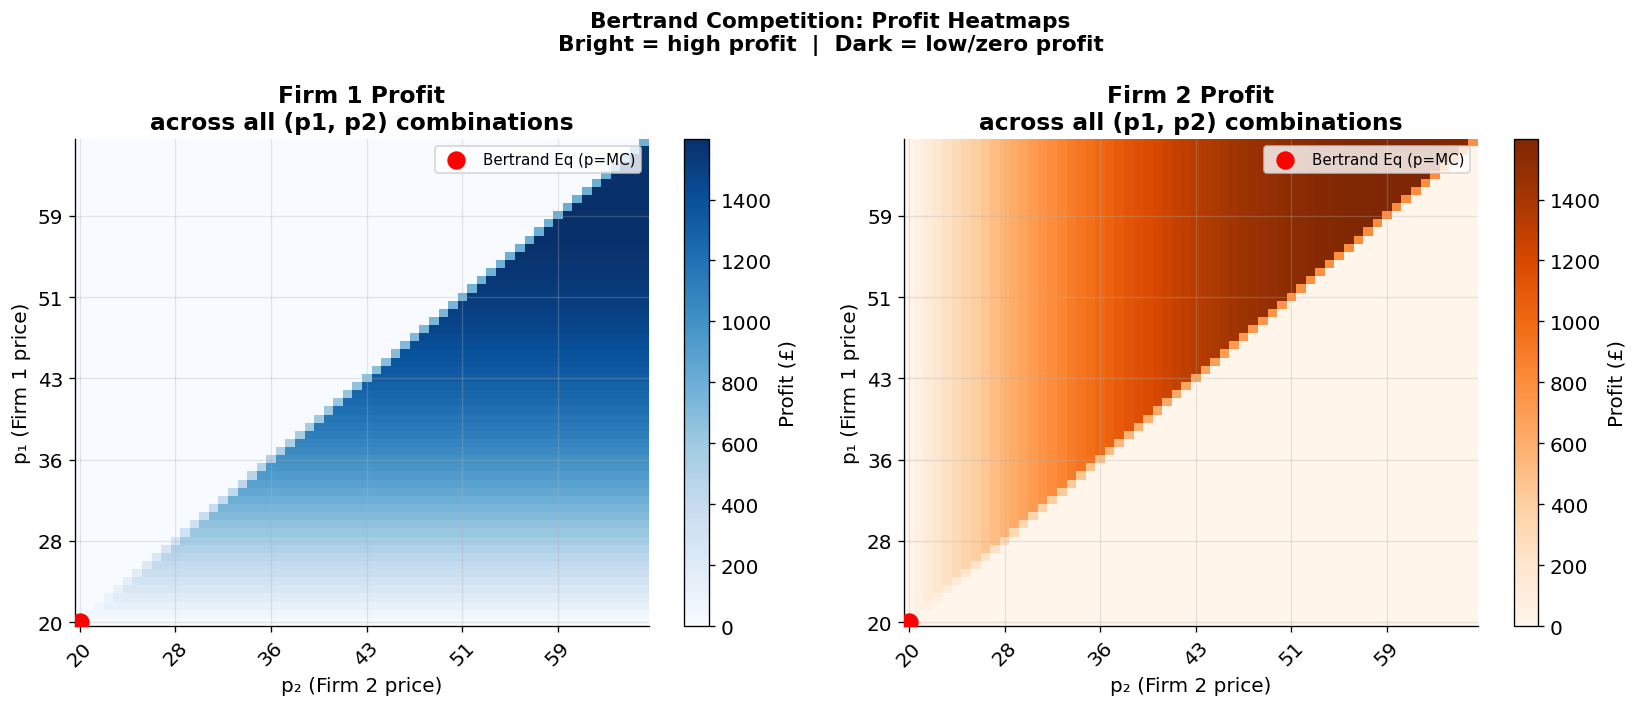

  ↑ Notice: each firm's highest profit (bright) occurs when
    IT prices low and the RIVAL prices HIGH — classic undercutting incentive.


In [ ]:
# ============================================================
# SECTION 4B: BERTRAND — PROFIT HEATMAP SIMULATION
# ============================================================
# Simulate profits across a grid of (p1, p2) combinations.
# This shows WHY firms are driven to undercut each other.

def simulate_bertrand_grid(a, b, c1, c2, n_points=60):
    """
    Evaluate Firm 1 and Firm 2 profits across an n×n price grid.
    Returns matrices of profits and the price axis.
    """
    # Price range: from MC up to monopoly price
    p_monopoly = (a + c1) / 2          # rough monopoly price
    prices = np.linspace(c1, p_monopoly * 1.1, n_points)

    profit1_grid = np.zeros((n_points, n_points))
    profit2_grid = np.zeros((n_points, n_points))

    for i, p1_val in enumerate(prices):
        for j, p2_val in enumerate(prices):
            pi1, pi2 = bertrand_profits(p1_val, p2_val, a, b, c1, c2)
            profit1_grid[i, j] = pi1
            profit2_grid[i, j] = pi2

    return prices, profit1_grid, profit2_grid


def plot_bertrand_heatmaps(a, b, c1, c2):
    """Plot side-by-side profit heatmaps for Firm 1 and Firm 2."""

    prices, grid1, grid2 = simulate_bertrand_grid(a, b, c1, c2)
    tick_labels = [f"{p:.0f}" for p in prices]
    step = len(prices) // 6    # show ~6 tick labels

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, grid, firm_label, cmap in zip(
            axes,
            [grid1, grid2],
            ['Firm 1', 'Firm 2'],
            ['Blues', 'Oranges']):

        im = ax.imshow(grid, origin='lower', aspect='auto',
                       cmap=cmap, interpolation='nearest')
        plt.colorbar(im, ax=ax, label='Profit (£)')

        ax.set_xticks(range(0, len(prices), step))
        ax.set_xticklabels(tick_labels[::step], rotation=45)
        ax.set_yticks(range(0, len(prices), step))
        ax.set_yticklabels(tick_labels[::step])

        ax.set_xlabel('p₂ (Firm 2 price)')
        ax.set_ylabel('p₁ (Firm 1 price)')
        ax.set_title(f'{firm_label} Profit\nacross all (p1, p2) combinations',
                     fontweight='bold')

        # Mark the Bertrand equilibrium point (p=MC → index 0)
        ax.scatter(0, 0, color='red', s=100, zorder=5,
                   label='Bertrand Eq (p=MC)')
        ax.legend(fontsize=9)

    plt.suptitle('Bertrand Competition: Profit Heatmaps\n'
                 'Bright = high profit  |  Dark = low/zero profit',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("  ↑ Notice: each firm's highest profit (bright) occurs when")
    print("    IT prices low and the RIVAL prices HIGH — classic undercutting incentive.")


plot_bertrand_heatmaps(a, b, c1, c2)

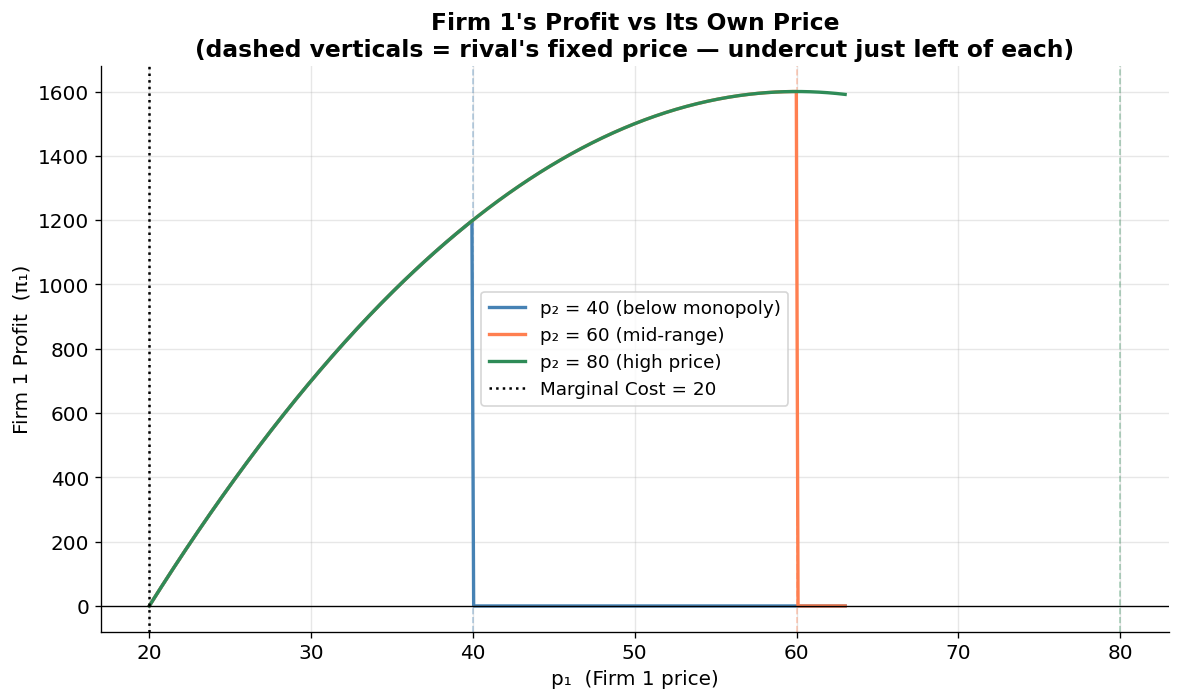

  ↑ Firm 1's profit spikes just BELOW the rival's price (capture full market),
    then drops to zero at p1 = p2 (split market), then zero again above (lose market).
    This discontinuity is the engine of Bertrand undercutting.


In [ ]:
# ============================================================
# SECTION 4C: UNDERCUTTING DYNAMICS
# ============================================================
# Fix Firm 2's price and show how Firm 1's profit changes
# as Firm 1 varies its own price → reveals the undercutting incentive.

def plot_undercutting_dynamics(a, b, c1, c2):
    """
    For three fixed values of p2, plot Firm 1's profit
    as a function of p1.  Shows the jump discontinuity
    at p1 = p2 that drives Bertrand undercutting.
    """
    p_mono  = (a + c1) / 2
    p1_vals = np.linspace(c1, p_mono * 1.05, 400)

    fixed_p2_values = {
        'p₂ = 40 (below monopoly)' : 40,
        'p₂ = 60 (mid-range)'      : 60,
        'p₂ = 80 (high price)'     : 80,
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['steelblue', 'coral', 'seagreen']

    for (label, p2_fixed), color in zip(fixed_p2_values.items(), colors):
        profits = [bertrand_profits(p1, p2_fixed, a, b, c1, c2)[0]
                   for p1 in p1_vals]
        ax.plot(p1_vals, profits, label=label, color=color, linewidth=2)

        # Mark the undercutting point (just below p2)
        ax.axvline(p2_fixed, color=color, linestyle='--', alpha=0.4, linewidth=1)

    ax.axvline(c1, color='black', linestyle=':', linewidth=1.5,
               label=f'Marginal Cost = {c1}')
    ax.axhline(0,  color='black', linewidth=0.8)

    ax.set_xlabel('p₁  (Firm 1 price)')
    ax.set_ylabel('Firm 1 Profit  (π₁)')
    ax.set_title("Firm 1's Profit vs Its Own Price\n"
                 "(dashed verticals = rival's fixed price — undercut just left of each)",
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("  ↑ Firm 1's profit spikes just BELOW the rival's price (capture full market),")
    print("    then drops to zero at p1 = p2 (split market), then zero again above (lose market).")
    print("    This discontinuity is the engine of Bertrand undercutting.")


plot_undercutting_dynamics(a, b, c1, c2)

---
## Section 5: Cournot vs Bertrand — Head-to-Head Comparison

### The Central Question
Which competition model produces better outcomes — and for whom?

| Dimension | Cournot | Bertrand |
|---|---|---|
| **Competition variable** | Quantity | Price |
| **Who benefits** | Producers | Consumers |
| **Price** | Above MC | = MC |
| **Profit** | Positive | Zero (symmetric) |
| **Real-world analogy** | Volume-based rivalry | Fee/rate wars |

We now compare both models side by side using our baseline parameters.

In [ ]:
# ============================================================
# SECTION 5A: COURNOT vs BERTRAND — SUMMARY COMPARISON TABLE
# ============================================================

def compare_models(a, b, c1, c2):
    """
    Run both models and return a unified comparison DataFrame.

    Parameters
    ----------
    a, b   : demand parameters
    c1, c2 : marginal costs

    Returns
    -------
    pandas DataFrame with side-by-side comparison
    """
    co = cournot_equilibrium(a, b, c1, c2)
    be = bertrand_equilibrium(a, b, c1, c2)

    # ── Consumer surplus: area under demand curve above price ─
    # CS = 0.5 * (a - P*) * Q*
    cs_cournot  = 0.5 * (a - co['P_star'])  * co['Q_star']
    cs_bertrand = 0.5 * (a - be['p_star'])  * be['Q_star']

    # ── Total welfare = CS + Producer Surplus (= total profit)
    tw_cournot  = cs_cournot  + co['total_profit']
    tw_bertrand = cs_bertrand + be['total_profit']

    comparison = {
        'Metric': [
            'Market Price  (P*)',
            'Total Quantity  (Q*)',
            'Firm 1 Quantity  (q1*)',
            'Firm 2 Quantity  (q2*)',
            'Firm 1 Profit  (π₁*)',
            'Firm 2 Profit  (π₂*)',
            'Total Industry Profit',
            'Consumer Surplus',
            'Total Welfare  (CS + PS)',
            'Price - MC  (markup)',
        ],
        'Cournot': [
            round(co['P_star'],       2),
            round(co['Q_star'],       2),
            round(co['q1_star'],      2),
            round(co['q2_star'],      2),
            round(co['profit1'],      2),
            round(co['profit2'],      2),
            round(co['total_profit'], 2),
            round(cs_cournot,         2),
            round(tw_cournot,         2),
            round(co['P_star'] - c1,  2),
        ],
        'Bertrand': [
            round(be['p_star'],        2),
            round(be['Q_star'],        2),
            round(be['Q_star'] / 2,    2),   # each gets half at tie
            round(be['Q_star'] / 2,    2),
            round(be['profit1'],       2),
            round(be['profit2'],       2),
            round(be['total_profit'],  2),
            round(cs_bertrand,         2),
            round(tw_bertrand,         2),
            round(be['p_star'] - c1,   2),
        ],
        'Better for...': [
            'Consumers  (Bertrand lower)',
            'Consumers  (Bertrand more)',
            '—',
            '—',
            'Producers  (Cournot positive)',
            'Producers  (Cournot positive)',
            'Producers  (Cournot positive)',
            'Consumers  (Bertrand higher)',
            'Society     (Bertrand higher)',
            'Producers  (Cournot has markup)',
        ]
    }

    return pd.DataFrame(comparison), co, be, cs_cournot, cs_bertrand, tw_cournot, tw_bertrand


# ── Run comparison ───────────────────────────────────────────
comp_df, co, be, cs_co, cs_be, tw_co, tw_be = compare_models(a, b, c1, c2)

print("=" * 75)
print("  COURNOT vs BERTRAND — COMPLETE COMPARISON TABLE")
print(f"  Baseline: a={a}, b={b}, c1={c1}, c2={c2}")
print("=" * 75)
print(comp_df.to_string(index=False))
print()
print("  VERDICT:")
print(f"  • Bertrand price    ({be['p_star']:.2f})  is {co['P_star'] - be['p_star']:.2f} lower than Cournot ({co['P_star']:.2f})")
print(f"  • Bertrand quantity ({be['Q_star']:.2f}) is {be['Q_star'] - co['Q_star']:.2f} higher than Cournot ({co['Q_star']:.2f})")
print(f"  • Cournot industry profit ({co['total_profit']:.2f}) vs Bertrand ({be['total_profit']:.2f})")
print(f"  • Bertrand total welfare  ({tw_be:.2f}) vs Cournot ({tw_co:.2f})")

  COURNOT vs BERTRAND — COMPLETE COMPARISON TABLE
  Baseline: a=100, b=1, c1=20, c2=20
                  Metric  Cournot  Bertrand                   Better for...
      Market Price  (P*)    46.67      20.0     Consumers  (Bertrand lower)
    Total Quantity  (Q*)    53.33      80.0      Consumers  (Bertrand more)
  Firm 1 Quantity  (q1*)    26.67      40.0                               —
  Firm 2 Quantity  (q2*)    26.67      40.0                               —
    Firm 1 Profit  (π₁*)   711.11       0.0   Producers  (Cournot positive)
    Firm 2 Profit  (π₂*)   711.11       0.0   Producers  (Cournot positive)
   Total Industry Profit  1422.22       0.0   Producers  (Cournot positive)
        Consumer Surplus  1422.22    3200.0    Consumers  (Bertrand higher)
Total Welfare  (CS + PS)  2844.44    3200.0   Society     (Bertrand higher)
    Price - MC  (markup)    26.67       0.0 Producers  (Cournot has markup)

  VERDICT:
  • Bertrand price    (20.00)  is 26.67 lower than Cournot (46.67

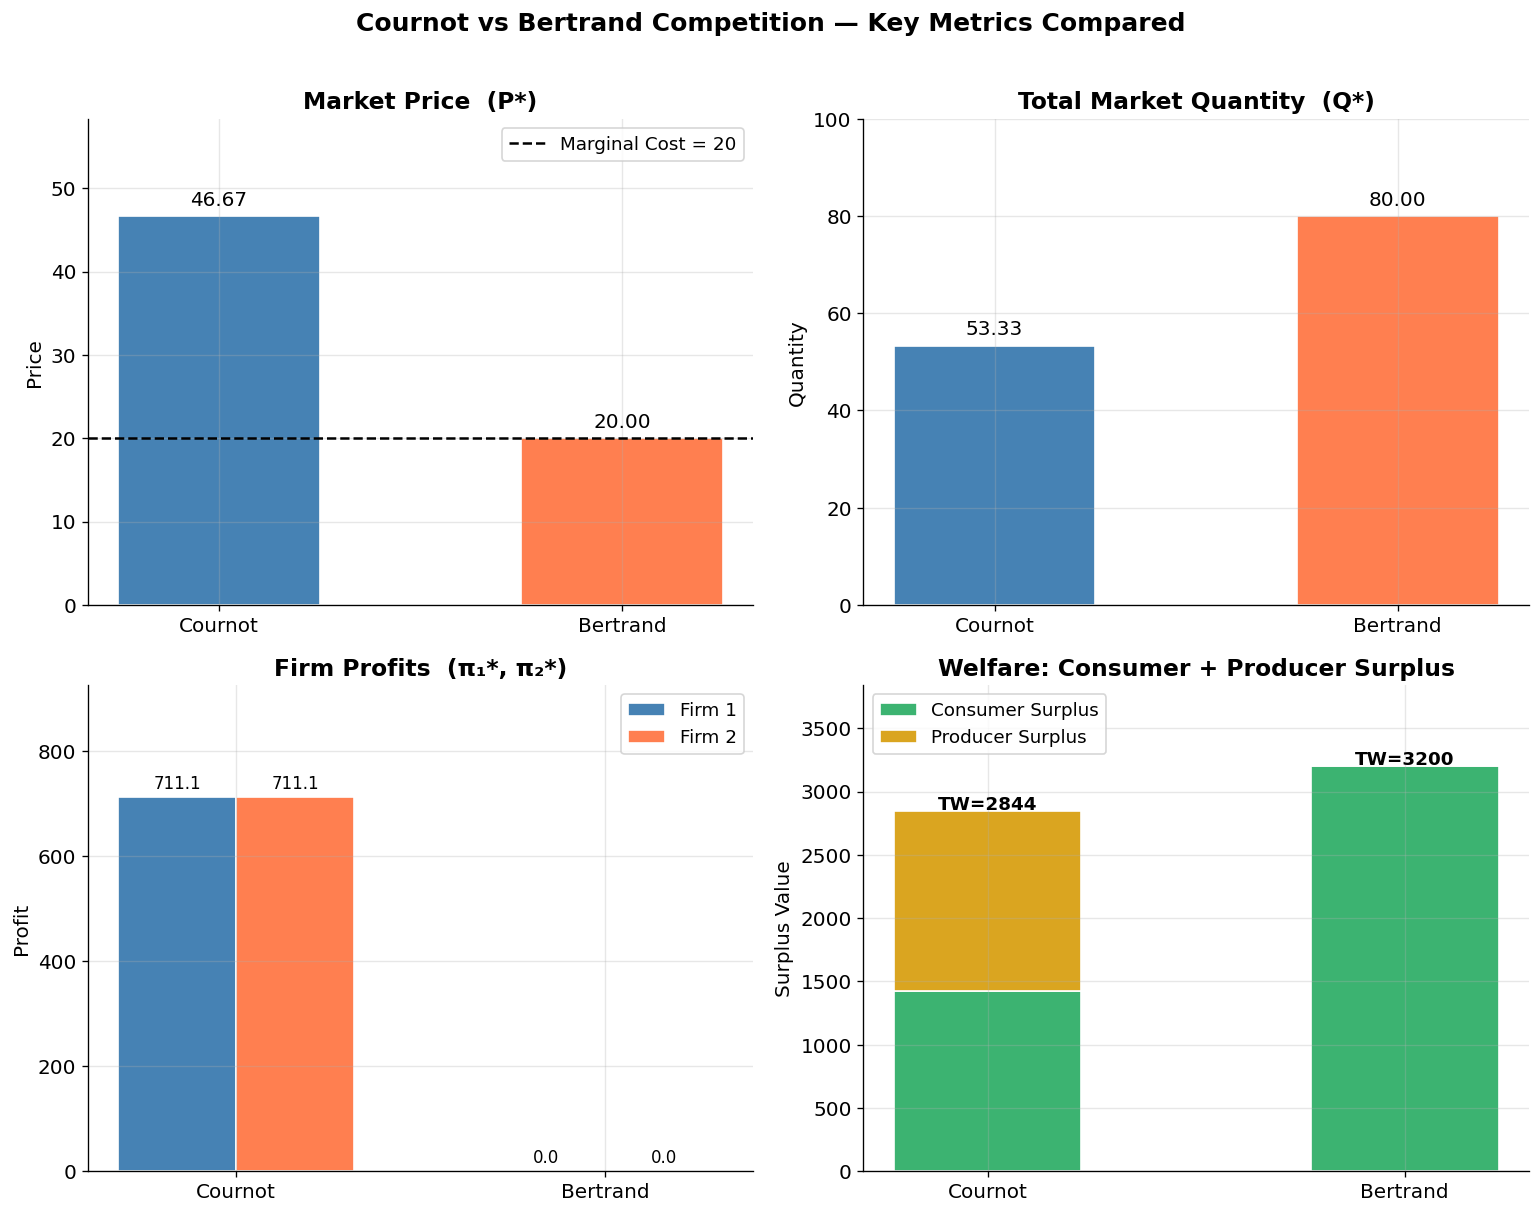

  ↑ Panel 1: Bertrand drives price to MC — no markup
  ↑ Panel 2: Bertrand produces more (efficient allocation)
  ↑ Panel 3: Cournot preserves positive profit for both firms
  ↑ Panel 4: Bertrand generates higher total welfare (less deadweight loss)


In [ ]:
# ============================================================
# SECTION 5B: COMPARISON BAR CHARTS
# ============================================================

def plot_model_comparison(co, be, cs_co, cs_be, tw_co, tw_be, c1):
    """
    Four-panel bar chart comparing Cournot vs Bertrand on:
    price, quantity, profits, and welfare.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle('Cournot vs Bertrand Competition — Key Metrics Compared',
                 fontsize=15, fontweight='bold', y=1.01)

    models  = ['Cournot', 'Bertrand']
    colors  = ['steelblue', 'coral']

    # ── Panel 1: Market Price ────────────────────────────────
    ax = axes[0, 0]
    bars = ax.bar(models,
                  [co['P_star'], be['p_star']],
                  color=colors, width=0.5, edgecolor='white')
    ax.axhline(c1, color='black', linestyle='--',
               linewidth=1.5, label=f'Marginal Cost = {c1}')
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)
    ax.set_title('Market Price  (P*)', fontweight='bold')
    ax.set_ylabel('Price')
    ax.legend()
    ax.set_ylim(0, max(co['P_star'], be['p_star']) * 1.25)

    # ── Panel 2: Total Quantity ──────────────────────────────
    ax = axes[0, 1]
    bars = ax.bar(models,
                  [co['Q_star'], be['Q_star']],
                  color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)
    ax.set_title('Total Market Quantity  (Q*)', fontweight='bold')
    ax.set_ylabel('Quantity')
    ax.set_ylim(0, max(co['Q_star'], be['Q_star']) * 1.25)

    # ── Panel 3: Firm Profits ────────────────────────────────
    ax = axes[1, 0]
    x       = np.arange(2)
    width   = 0.32
    b1 = ax.bar(x - width/2,
                [co['profit1'],  be['profit1']],
                width, label='Firm 1', color='steelblue', edgecolor='white')
    b2 = ax.bar(x + width/2,
                [co['profit2'],  be['profit2']],
                width, label='Firm 2', color='coral', edgecolor='white')
    ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=10)
    ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title('Firm Profits  (π₁*, π₂*)', fontweight='bold')
    ax.set_ylabel('Profit')
    ax.legend()
    ax.set_ylim(0, max(co['profit1'], co['profit2']) * 1.3)

    # ── Panel 4: Welfare Breakdown ───────────────────────────
    ax = axes[1, 1]
    x      = np.arange(2)
    width  = 0.45
    cs_vals = [cs_co, cs_be]
    ps_vals = [co['total_profit'], be['total_profit']]

    bars_cs = ax.bar(x, cs_vals, width,
                     label='Consumer Surplus', color='mediumseagreen',
                     edgecolor='white')
    bars_ps = ax.bar(x, ps_vals, width,
                     bottom=cs_vals, label='Producer Surplus',
                     color='goldenrod', edgecolor='white')

    # Total welfare labels on top
    for i, (cs_v, ps_v) in enumerate(zip(cs_vals, ps_vals)):
        ax.text(i, cs_v + ps_v + 15, f'TW={cs_v+ps_v:.0f}',
                ha='center', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title('Welfare: Consumer + Producer Surplus', fontweight='bold')
    ax.set_ylabel('Surplus Value')
    ax.legend()
    ax.set_ylim(0, max(tw_co, tw_be) * 1.2)

    plt.tight_layout()
    plt.show()

    print("  ↑ Panel 1: Bertrand drives price to MC — no markup")
    print("  ↑ Panel 2: Bertrand produces more (efficient allocation)")
    print("  ↑ Panel 3: Cournot preserves positive profit for both firms")
    print("  ↑ Panel 4: Bertrand generates higher total welfare (less deadweight loss)")


plot_model_comparison(co, be, cs_co, cs_be, tw_co, tw_be, c1)

In [ ]:
# ============================================================
# SECTION 5C: FINANCE INTERPRETATION
# ============================================================

finance_df = pd.DataFrame({
    'Real-World Setting': [
        'Banks — loan rates',
        'Banks — deposit rates',
        'Brokers — trading fees',
        'Fintechs — pricing',
        'Insurers — premiums',
        'Underwriters — deal volume',
    ],
    'Competition Type': [
        'Bertrand (rate war)',
        'Bertrand (rate war)',
        'Bertrand (fee war)',
        'Bertrand (price war)',
        'Bertrand (premium war)',
        'Cournot (volume control)',
    ],
    'Cournot Analogy': [
        'Banks cap lending volume to preserve spread',
        'Banks limit deposit products to maintain NIM',
        'Brokers limit service tiers, not headline fee',
        'Firms differentiate product to avoid commodity trap',
        'Insurers segment risk pools to avoid race to bottom',
        'Banks/ECM desks manage deal flow like quantity',
    ],
    'Key Lesson': [
        'Rate competition compresses NIM → Bertrand outcome',
        'Deposit wars erode funding cost advantage',
        'Zero-fee race hurts all incumbents equally',
        'Commoditised fintechs earn near-zero margin',
        'Homogeneous cover → price = actuarial cost',
        'Cournot logic: control supply to protect margins',
    ]
})

print("=" * 100)
print("  FINANCE INTERPRETATION: WHERE DO COURNOT AND BERTRAND APPEAR IN REAL MARKETS?")
print("=" * 100)
print(finance_df.to_string(index=False))
print()
print("  KEY TAKEAWAYS FOR FINANCE:")
print("  ─" * 35)
print(f"""
  1. BERTRAND → MARGIN COMPRESSION
     When two banks, brokers, or fintechs offer identical services,
     price competition drives margins toward zero — exactly as the
     model predicts. Example: zero-commission trading (Robinhood effect).

  2. COURNOT → VOLUME DISCIPLINE
     Firms that compete on volume (lending quotas, underwriting capacity,
     insurance policy limits) can preserve margins. Investment banks
     managing deal pipelines behave more like Cournot players.

  3. COST ADVANTAGE IS DECISIVE IN BERTRAND
     A fintech with lower unit costs (c1 < c2) can undercut the incumbent
     and capture the entire market while still earning positive profit.
     This is the disruption playbook.

  4. PRODUCT DIFFERENTIATION ESCAPES THE PARADOX
     If services are not perfectly homogeneous, Bertrand competition
     softens — firms retain some pricing power. This is why banks
     invest heavily in brand, relationships, and product features.

  Cournot Price:    {co['P_star']:.2f}  |  Markup over MC: {co['P_star']-c1:.2f}
  Bertrand Price:   {be['p_star']:.2f}  |  Markup over MC: {be['p_star']-c1:.2f}
  Profit loss from Bertrand: {co['total_profit'] - be['total_profit']:.2f} (industry-wide)
""")

  FINANCE INTERPRETATION: WHERE DO COURNOT AND BERTRAND APPEAR IN REAL MARKETS?
        Real-World Setting         Competition Type                                     Cournot Analogy                                         Key Lesson
        Banks — loan rates      Bertrand (rate war)         Banks cap lending volume to preserve spread Rate competition compresses NIM → Bertrand outcome
     Banks — deposit rates      Bertrand (rate war)        Banks limit deposit products to maintain NIM          Deposit wars erode funding cost advantage
    Brokers — trading fees       Bertrand (fee war)       Brokers limit service tiers, not headline fee         Zero-fee race hurts all incumbents equally
        Fintechs — pricing     Bertrand (price war) Firms differentiate product to avoid commodity trap        Commoditised fintechs earn near-zero margin
       Insurers — premiums   Bertrand (premium war) Insurers segment risk pools to avoid race to bottom         Homogeneous cover → price = actua

---
## Section 6: Sensitivity Analysis

### What are we testing?
Real markets don't have fixed parameters. We now stress-test both models
by varying one parameter at a time while holding others constant.

| Parameter varied | Economic Question |
|---|---|
| **Demand intercept `a`** | What if the market grows or shrinks? |
| **Demand slope `b`** | What if demand becomes more/less elastic? |
| **Marginal cost `c1`** | What if Firm 1 becomes more/less efficient? |
| **Marginal cost `c2`** | What if Firm 2 becomes more/less efficient? |

### Finance parallels
- `a` rising → growing loan demand, more AUM, expanding fintech TAM
- `b` rising → more price-sensitive customers (commoditised market)
- `c1` falling → one bank adopts cheaper technology (cost disruption)

In [ ]:
# ============================================================
# SECTION 6A: SENSITIVITY ANALYSIS — CORE ENGINE
# ============================================================

def run_sensitivity_analysis(param_name, param_values,
                              base_a, base_b, base_c1, base_c2):
    """
    Vary one parameter across a range while holding others fixed.
    Computes Cournot and Bertrand equilibria at each value.

    Parameters
    ----------
    param_name   : which parameter to vary ('a','b','c1','c2')
    param_values : array of values to test
    base_*       : baseline values for all parameters

    Returns
    -------
    pandas DataFrame with results across all parameter values
    """
    records = []

    for val in param_values:

        # Assign varied parameter, keep rest at baseline
        a_  = val      if param_name == 'a'  else base_a
        b_  = val      if param_name == 'b'  else base_b
        c1_ = val      if param_name == 'c1' else base_c1
        c2_ = val      if param_name == 'c2' else base_c2

        # Skip invalid combinations (MC above demand intercept)
        if a_ <= max(c1_, c2_):
            continue

        co_ = cournot_equilibrium(a_, b_, c1_, c2_)
        be_ = bertrand_equilibrium(a_, b_, c1_, c2_)

        # Consumer surplus under each model
        cs_co_ = 0.5 * (a_ - co_['P_star']) * co_['Q_star']
        cs_be_ = 0.5 * (a_ - be_['p_star']) * be_['Q_star']

        records.append({
            'param_name'        : param_name,
            'param_value'       : round(val, 4),

            # Cournot outcomes
            'co_price'          : round(co_['P_star'],        4),
            'co_quantity'       : round(co_['Q_star'],        4),
            'co_profit1'        : round(co_['profit1'],       4),
            'co_profit2'        : round(co_['profit2'],       4),
            'co_total_profit'   : round(co_['total_profit'],  4),
            'co_consumer_surplus': round(cs_co_,              4),

            # Bertrand outcomes
            'be_price'          : round(be_['p_star'],        4),
            'be_quantity'       : round(be_['Q_star'],        4),
            'be_profit1'        : round(be_['profit1'],       4),
            'be_profit2'        : round(be_['profit2'],       4),
            'be_total_profit'   : round(be_['total_profit'],  4),
            'be_consumer_surplus': round(cs_be_,              4),

            # Spread between models
            'price_gap'         : round(co_['P_star'] - be_['p_star'],       4),
            'quantity_gap'      : round(be_['Q_star'] - co_['Q_star'],        4),
            'profit_gap'        : round(co_['total_profit'] - be_['total_profit'], 4),
        })

    return pd.DataFrame(records)


# ── Run all four sensitivity sweeps ─────────────────────────

# 1. Vary demand intercept a (50 → 150)
df_sens_a  = run_sensitivity_analysis(
    'a',  np.linspace(50,  150, 50), a, b, c1, c2)

# 2. Vary demand slope b (0.5 → 3.0)
df_sens_b  = run_sensitivity_analysis(
    'b',  np.linspace(0.5,  3.0, 50), a, b, c1, c2)

# 3. Vary Firm 1 marginal cost c1 (5 → 60)
df_sens_c1 = run_sensitivity_analysis(
    'c1', np.linspace(5,   60,  50), a, b, c1, c2)

# 4. Vary Firm 2 marginal cost c2 (5 → 60)
df_sens_c2 = run_sensitivity_analysis(
    'c2', np.linspace(5,   60,  50), a, b, c1, c2)

print("✅ Sensitivity analysis complete.")
print(f"   Sweep over 'a'  → {len(df_sens_a)}  scenarios")
print(f"   Sweep over 'b'  → {len(df_sens_b)}  scenarios")
print(f"   Sweep over 'c1' → {len(df_sens_c1)} scenarios")
print(f"   Sweep over 'c2' → {len(df_sens_c2)} scenarios")
print()

# ── Preview: vary a ──────────────────────────────────────────
print("Sample output — varying demand intercept (a):")
print(df_sens_a[['param_value','co_price','be_price',
                  'co_total_profit','be_total_profit',
                  'price_gap']].iloc[::10].to_string(index=False))

✅ Sensitivity analysis complete.
   Sweep over 'a'  → 50  scenarios
   Sweep over 'b'  → 50  scenarios
   Sweep over 'c1' → 50 scenarios
   Sweep over 'c2' → 50 scenarios

Sample output — varying demand intercept (a):
 param_value  co_price  be_price  co_total_profit  be_total_profit  price_gap
     50.0000   30.0000        20         200.0000              0.0    10.0000
     70.4082   36.8027        20         564.6629              0.0    16.8027
     90.8163   43.6054        20        1114.4338              0.0    23.6054
    111.2245   50.4082        20        1849.3128              0.0    30.4082
    131.6327   57.2109        20        2769.2998              0.0    37.2109


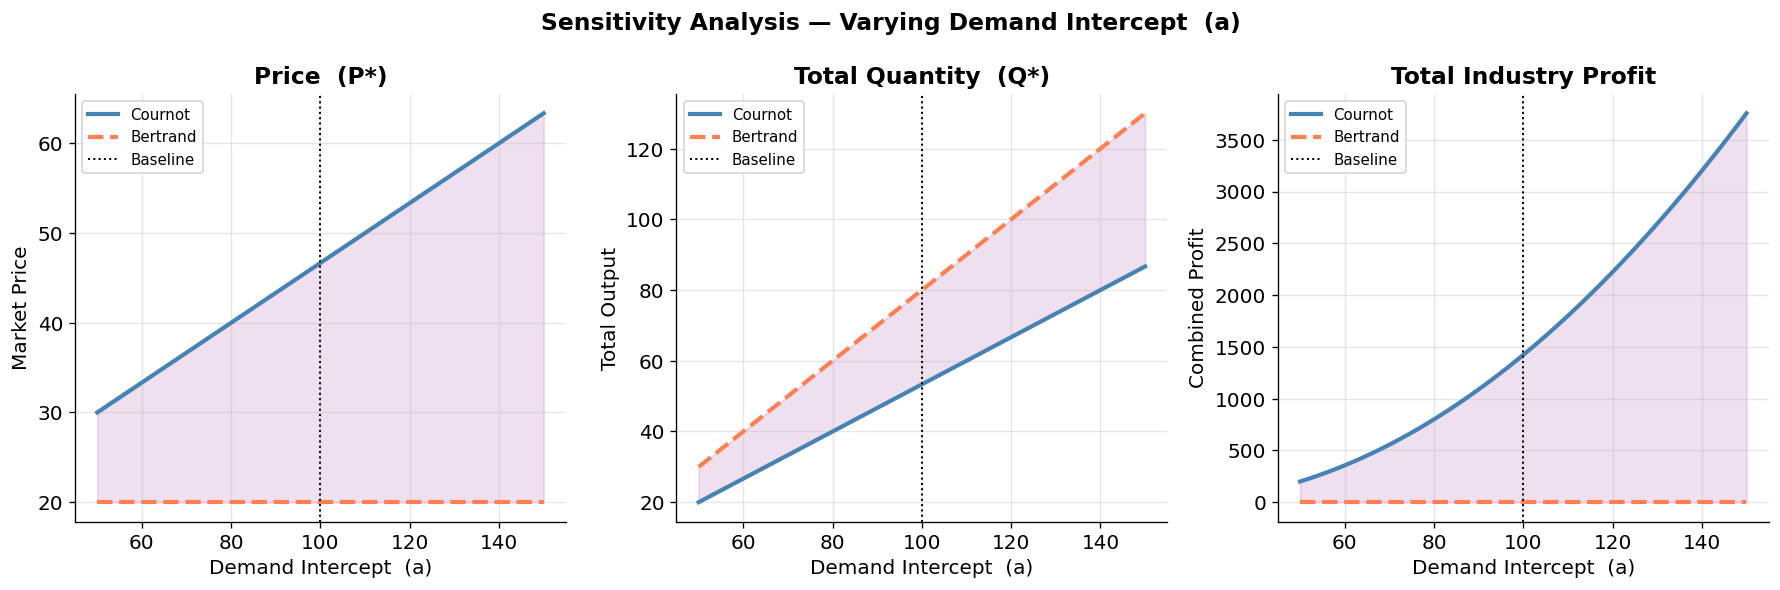

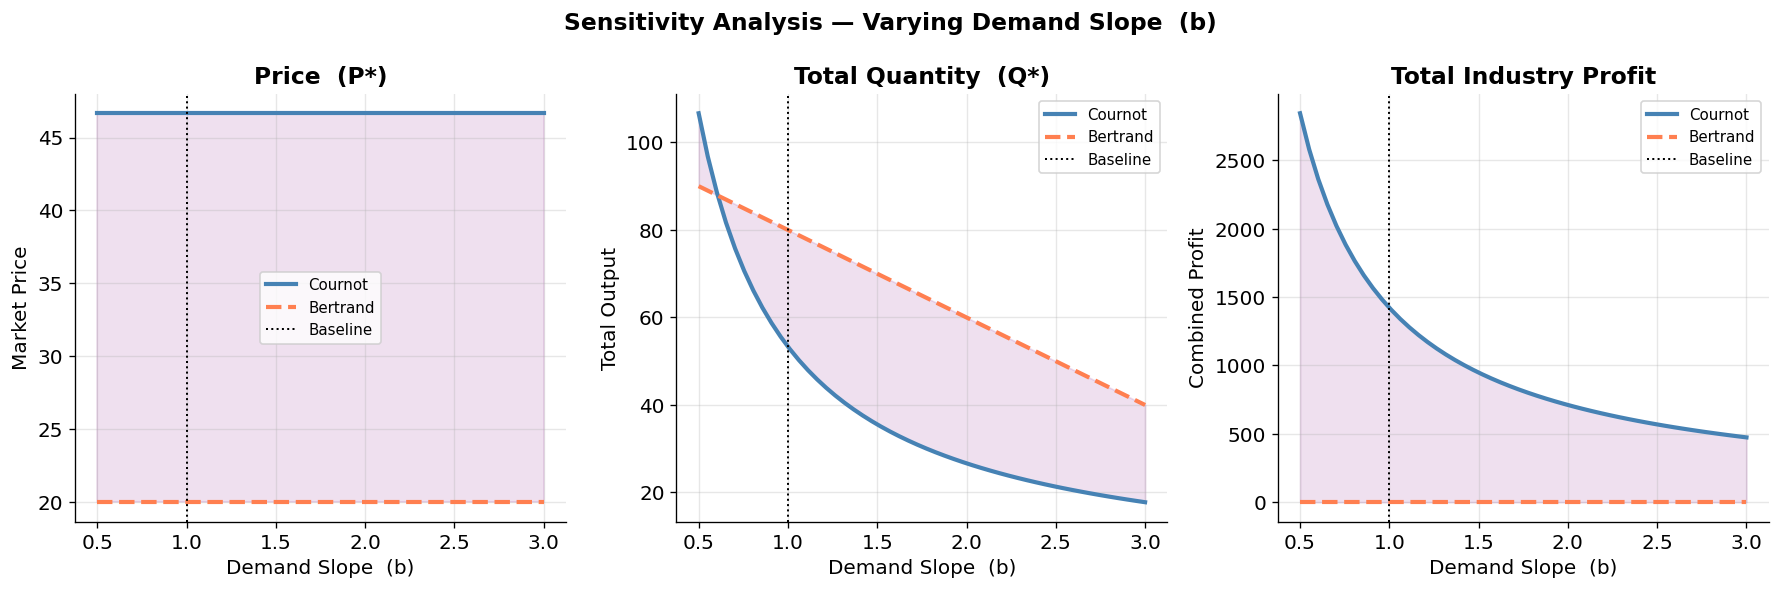

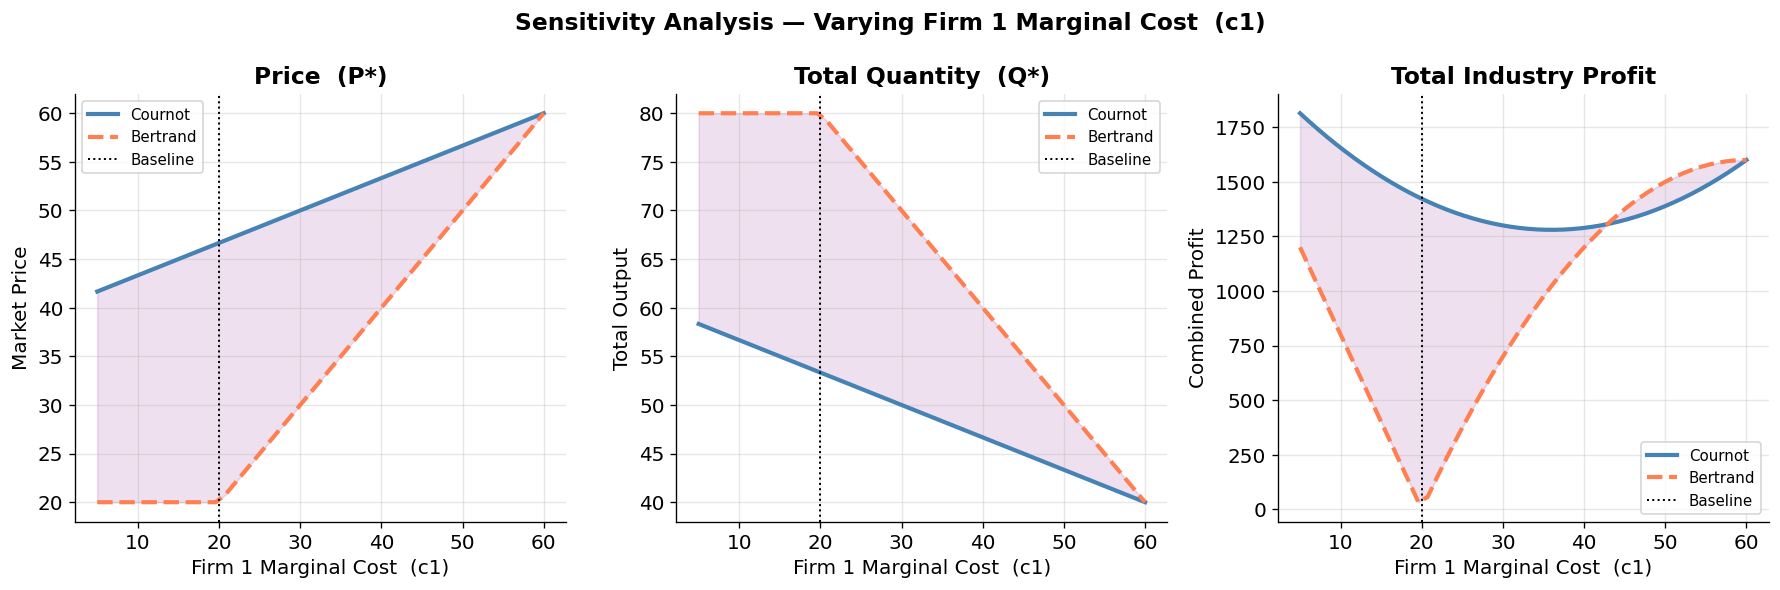

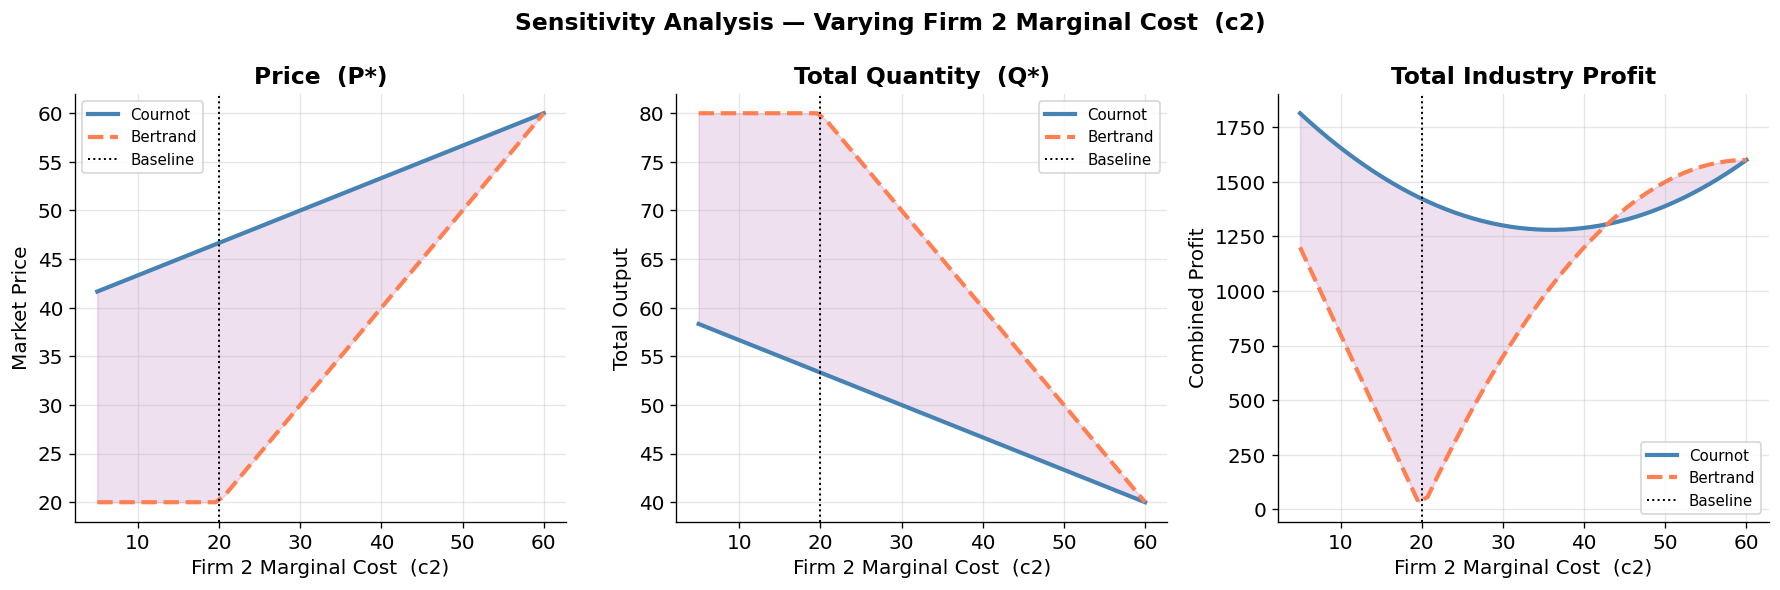

In [ ]:
# ============================================================
# SECTION 6B: SENSITIVITY — LINE PLOTS (4 SWEEPS × 3 METRICS)
# ============================================================

def plot_sensitivity(df, param_label, param_col='param_value'):
    """
    Three-panel sensitivity plot for one parameter sweep.
    Shows Price, Total Quantity, and Total Profit for both models.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sensitivity Analysis — Varying {param_label}',
                 fontsize=14, fontweight='bold')

    x = df[param_col]

    panels = [
        ('Price  (P*)',
         'co_price',        'be_price',
         'Market Price'),
        ('Total Quantity  (Q*)',
         'co_quantity',     'be_quantity',
         'Total Output'),
        ('Total Industry Profit',
         'co_total_profit', 'be_total_profit',
         'Combined Profit'),
    ]

    for ax, (title, co_col, be_col, ylabel) in zip(axes, panels):
        ax.plot(x, df[co_col], color='steelblue',
                linewidth=2.5, label='Cournot')
        ax.plot(x, df[be_col], color='coral',
                linewidth=2.5, label='Bertrand', linestyle='--')

        # Shade the gap between models
        ax.fill_between(x, df[co_col], df[be_col],
                        alpha=0.12, color='purple')

        # Mark baseline parameter value
        baseline_map = {'a': a, 'b': b, 'c1': c1, 'c2': c2}
        key = df['param_name'].iloc[0]
        ax.axvline(baseline_map[key], color='black',
                   linestyle=':', linewidth=1.2, label='Baseline')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(param_label)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


# ── Plot all four sweeps ─────────────────────────────────────
plot_sensitivity(df_sens_a,  "Demand Intercept  (a)")
plot_sensitivity(df_sens_b,  "Demand Slope  (b)")
plot_sensitivity(df_sens_c1, "Firm 1 Marginal Cost  (c1)")
plot_sensitivity(df_sens_c2, "Firm 2 Marginal Cost  (c2)")

In [ ]:
# ============================================================
# SECTION 6C: SENSITIVITY — SUMMARY INSIGHT TABLE
# ============================================================

def sensitivity_summary(df, param_label):
    """
    For a given sensitivity sweep, extract min/max/direction
    for price, quantity, and profit under each model.
    """
    rows = []
    for col, label in [
        ('co_price',        'Cournot Price'),
        ('be_price',        'Bertrand Price'),
        ('co_total_profit', 'Cournot Profit'),
        ('be_total_profit', 'Bertrand Profit'),
        ('co_quantity',     'Cournot Quantity'),
        ('be_quantity',     'Bertrand Quantity'),
    ]:
        direction = ('↑ rises' if df[col].iloc[-1] > df[col].iloc[0]
                     else '↓ falls')
        rows.append({
            'Metric'        : label,
            'Min value'     : round(df[col].min(), 2),
            'Max value'     : round(df[col].max(), 2),
            'Direction'     : direction,
        })

    summary = pd.DataFrame(rows)
    print(f"\n  As {param_label} increases:")
    print(summary.to_string(index=False))
    print()


print("=" * 60)
print("  SENSITIVITY SUMMARY — DIRECTIONAL EFFECTS")
print("=" * 60)
sensitivity_summary(df_sens_a,  "Demand Intercept (a)")
sensitivity_summary(df_sens_b,  "Demand Slope (b)")
sensitivity_summary(df_sens_c1, "Firm 1 Marginal Cost (c1)")
sensitivity_summary(df_sens_c2, "Firm 2 Marginal Cost (c2)")

  SENSITIVITY SUMMARY — DIRECTIONAL EFFECTS

  As Demand Intercept (a) increases:
           Metric  Min value  Max value Direction
    Cournot Price       30.0      63.33   ↑ rises
   Bertrand Price       20.0      20.00   ↓ falls
   Cournot Profit      200.0    3755.56   ↑ rises
  Bertrand Profit        0.0       0.00   ↓ falls
 Cournot Quantity       20.0      86.67   ↑ rises
Bertrand Quantity       30.0     130.00   ↑ rises


  As Demand Slope (b) increases:
           Metric  Min value  Max value Direction
    Cournot Price      46.67      46.67   ↓ falls
   Bertrand Price      20.00      20.00   ↓ falls
   Cournot Profit     474.07    2844.44   ↓ falls
  Bertrand Profit       0.00       0.00   ↓ falls
 Cournot Quantity      17.78     106.67   ↓ falls
Bertrand Quantity      40.00      90.00   ↓ falls


  As Firm 1 Marginal Cost (c1) increases:
           Metric  Min value  Max value Direction
    Cournot Price      41.67      60.00   ↑ rises
   Bertrand Price      20.00      60.00

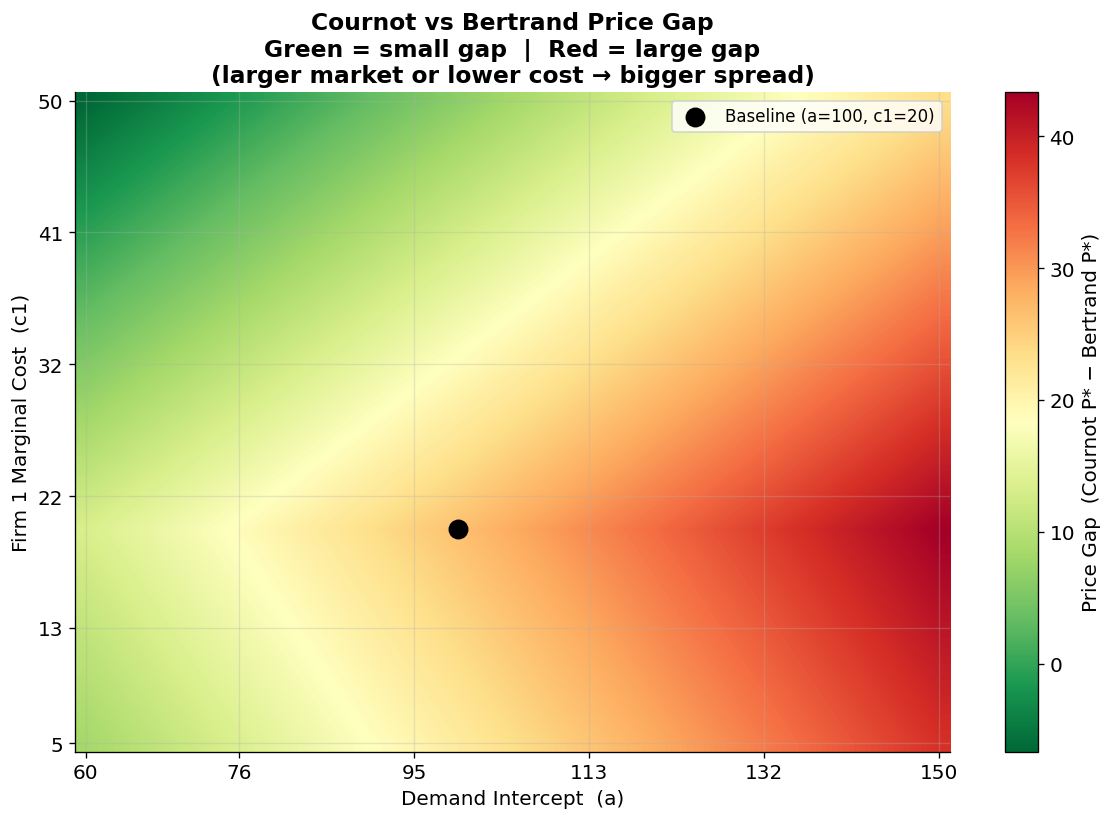

  ↑ Red zones = markets where Cournot gives firms much higher prices than Bertrand.
    These are markets where moving from price to quantity competition
    most benefits producers (and most hurts consumers).


In [ ]:
# ============================================================
# SECTION 6D: PRICE GAP HEATMAP — a vs c1 GRID
# ============================================================
# How does the Cournot-Bertrand price gap change
# as both demand AND cost shift simultaneously?

def plot_price_gap_heatmap(base_b, base_c2):
    """
    2D heatmap: x = demand intercept a, y = Firm 1 MC c1
    Color = (Cournot price − Bertrand price)
    """
    a_vals  = np.linspace(60, 150, 40)
    c1_vals = np.linspace(5,  50,  40)

    gap_matrix = np.zeros((len(c1_vals), len(a_vals)))

    for i, c1_val in enumerate(c1_vals):
        for j, a_val in enumerate(a_vals):
            if a_val <= max(c1_val, base_c2):
                gap_matrix[i, j] = np.nan
                continue
            co_ = cournot_equilibrium(a_val, base_b, c1_val, base_c2)
            be_ = bertrand_equilibrium(a_val, base_b, c1_val, base_c2)
            gap_matrix[i, j] = co_['P_star'] - be_['p_star']

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(gap_matrix, origin='lower', aspect='auto',
                   cmap='RdYlGn_r', interpolation='bilinear')
    plt.colorbar(im, ax=ax, label='Price Gap  (Cournot P* − Bertrand P*)')

    # Axis ticks
    xt = np.linspace(0, len(a_vals)-1, 6, dtype=int)
    yt = np.linspace(0, len(c1_vals)-1, 6, dtype=int)
    ax.set_xticks(xt);  ax.set_xticklabels([f"{a_vals[i]:.0f}"  for i in xt])
    ax.set_yticks(yt);  ax.set_yticklabels([f"{c1_vals[i]:.0f}" for i in yt])

    ax.set_xlabel('Demand Intercept  (a)')
    ax.set_ylabel('Firm 1 Marginal Cost  (c1)')
    ax.set_title('Cournot vs Bertrand Price Gap\n'
                 'Green = small gap  |  Red = large gap\n'
                 '(larger market or lower cost → bigger spread)',
                 fontweight='bold')

    # Mark baseline
    base_a_idx  = np.argmin(np.abs(a_vals  - a))
    base_c1_idx = np.argmin(np.abs(c1_vals - c1))
    ax.scatter(base_a_idx, base_c1_idx, color='black',
               s=120, zorder=5, label=f'Baseline (a={a}, c1={c1})')
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()
    print("  ↑ Red zones = markets where Cournot gives firms much higher prices than Bertrand.")
    print("    These are markets where moving from price to quantity competition")
    print("    most benefits producers (and most hurts consumers).")


plot_price_gap_heatmap(base_b=b, base_c2=c2)

---
## Section 7: Asymmetric Firms — When One Firm Has a Cost Advantage

### Why asymmetry matters
So far both firms had identical costs (c1 = c2 = 20).
Real markets are almost never symmetric.

| Scenario | Who has the edge | Finance parallel |
|---|---|---|
| c1 < c2 | Firm 1 (efficient) | Fintech vs incumbent bank |
| c1 > c2 | Firm 2 (efficient) | New low-cost broker vs legacy broker |
| Large gap | Dominant firm | Cloud-native insurer vs traditional insurer |

### What changes?
- **Cournot**: efficient firm produces more, earns higher profit
- **Bertrand**: efficient firm undercuts rival's MC, captures entire market
- **Disruption logic**: cost advantage is enough to eliminate competition

In [ ]:
# ============================================================
# SECTION 7A: ASYMMETRIC FIRMS — SCENARIO ANALYSIS
# ============================================================

def run_asymmetric_scenarios(a, b):
    """
    Run Cournot and Bertrand equilibria across a set of
    pre-defined asymmetric cost scenarios.

    Returns
    -------
    pandas DataFrame comparing all scenarios side by side
    """
    scenarios = {
        'Symmetric  (baseline)' : (20, 20),
        'Mild asymmetry'        : (15, 25),
        'Moderate asymmetry'    : (10, 30),
        'Strong asymmetry'      : (5,  35),
        'Extreme asymmetry'     : (5,  45),
        'Reversed (F2 cheaper)' : (30, 15),
    }

    records = []

    for name, (c1_, c2_) in scenarios.items():
        if a <= max(c1_, c2_):
            continue

        co_ = cournot_equilibrium(a, b, c1_, c2_)
        be_ = bertrand_equilibrium(a, b, c1_, c2_)

        cs_co_ = 0.5 * (a - co_['P_star']) * co_['Q_star']
        cs_be_ = 0.5 * (a - be_['p_star']) * be_['Q_star']

        records.append({
            'Scenario'          : name,
            'c1'                : c1_,
            'c2'                : c2_,
            'Cost gap (c2-c1)'  : c2_ - c1_,

            # Cournot
            'CO: q1*'           : round(co_['q1_star'],     2),
            'CO: q2*'           : round(co_['q2_star'],     2),
            'CO: Price'         : round(co_['P_star'],      2),
            'CO: π₁'            : round(co_['profit1'],     2),
            'CO: π₂'            : round(co_['profit2'],     2),
            'CO: Total π'       : round(co_['total_profit'],2),

            # Bertrand
            'BE: Price'         : round(be_['p_star'],      4),
            'BE: π₁'            : round(be_['profit1'],     2),
            'BE: π₂'            : round(be_['profit2'],     2),
            'BE: Winner'        : be_['winner'],
        })

    return pd.DataFrame(records)


df_asym = run_asymmetric_scenarios(a, b)

# ── Print Cournot view ───────────────────────────────────────
print("=" * 78)
print("  ASYMMETRIC FIRMS — COURNOT EQUILIBRIUM")
print(f"  (a={a}, b={b})")
print("=" * 78)
cournot_view = df_asym[['Scenario','c1','c2','Cost gap (c2-c1)',
                          'CO: q1*','CO: q2*','CO: Price',
                          'CO: π₁','CO: π₂','CO: Total π']]
print(cournot_view.to_string(index=False))

print()
print("=" * 78)
print("  ASYMMETRIC FIRMS — BERTRAND EQUILIBRIUM")
print("=" * 78)
bertrand_view = df_asym[['Scenario','c1','c2','Cost gap (c2-c1)',
                           'BE: Price','BE: π₁','BE: π₂','BE: Winner']]
print(bertrand_view.to_string(index=False))

  ASYMMETRIC FIRMS — COURNOT EQUILIBRIUM
  (a=100, b=1)
             Scenario  c1  c2  Cost gap (c2-c1)  CO: q1*  CO: q2*  CO: Price  CO: π₁  CO: π₂  CO: Total π
Symmetric  (baseline)  20  20                 0    26.67    26.67      46.67  711.11  711.11      1422.22
       Mild asymmetry  15  25                10    31.67    21.67      46.67 1002.78  469.44      1472.22
   Moderate asymmetry  10  30                20    36.67    16.67      46.67 1344.44  277.78      1622.22
     Strong asymmetry   5  35                30    41.67    11.67      46.67 1736.11  136.11      1872.22
    Extreme asymmetry   5  45                40    45.00     5.00      50.00 2025.00   25.00      2050.00
Reversed (F2 cheaper)  30  15               -15    18.33    33.33      48.33  336.11 1111.11      1447.22

  ASYMMETRIC FIRMS — BERTRAND EQUILIBRIUM
             Scenario  c1  c2  Cost gap (c2-c1)  BE: Price  BE: π₁  BE: π₂          BE: Winner
Symmetric  (baseline)  20  20                 0       20.0     0

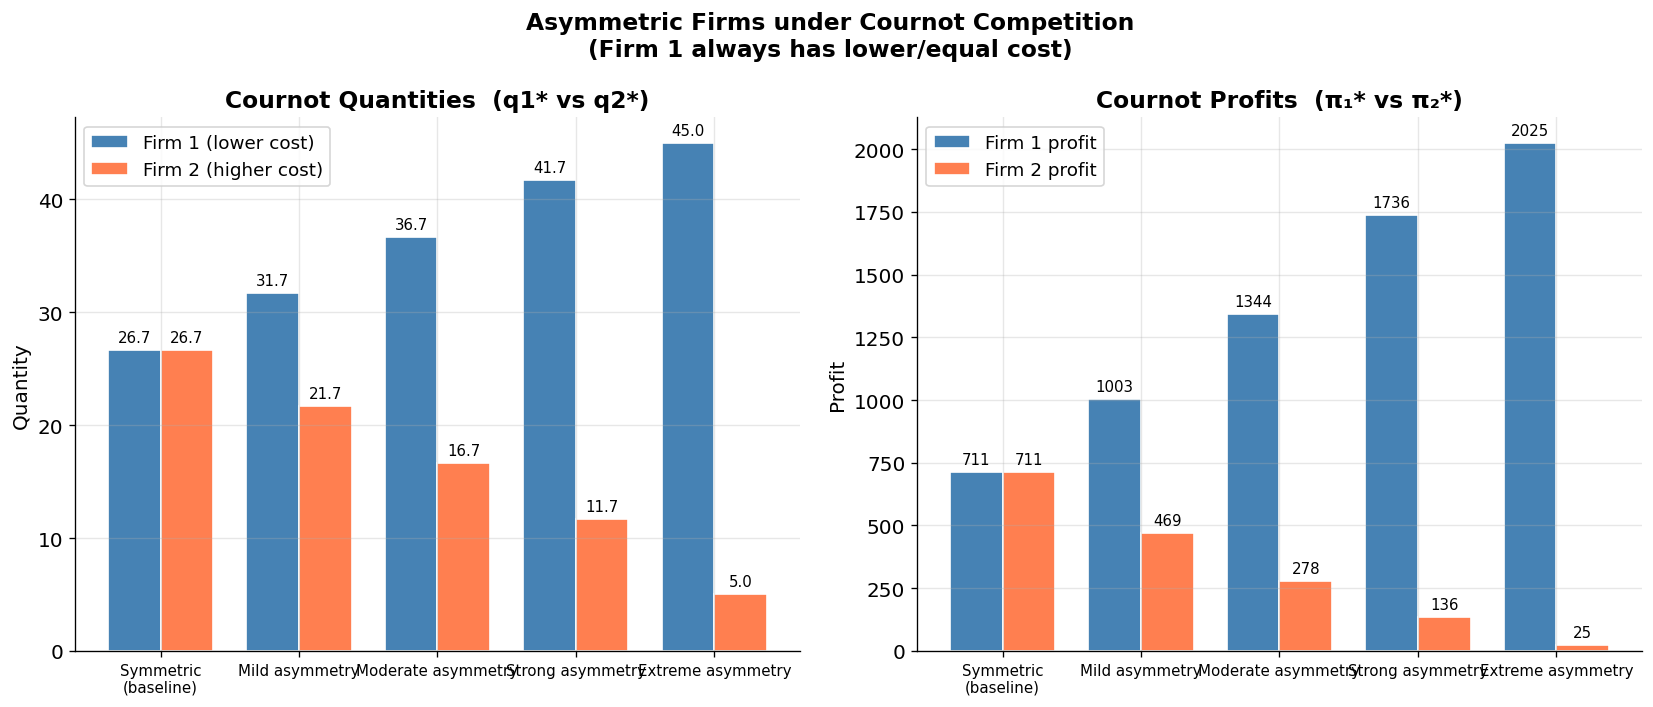

  ↑ As cost gap widens: Firm 1 produces more and earns far more.
    Firm 2 shrinks but survives — Cournot competition never fully
    eliminates a less efficient rival.


In [ ]:
# ============================================================
# SECTION 7B: ASYMMETRIC — QUANTITY & PROFIT VISUALISATIONS
# ============================================================

def plot_asymmetric_cournot(df_asym):
    """
    Two-panel chart showing how cost asymmetry shifts
    Cournot quantities and profits between firms.
    """
    # Use only the cost-gap scenarios (exclude 'Reversed')
    df_plot = df_asym[~df_asym['Scenario'].str.contains('Reversed')].copy()
    labels  = df_plot['Scenario'].str.replace('  ', '\n')
    x       = np.arange(len(df_plot))
    width   = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Asymmetric Firms under Cournot Competition\n'
                 '(Firm 1 always has lower/equal cost)',
                 fontsize=14, fontweight='bold')

    # ── Panel 1: Quantities ──────────────────────────────────
    ax = axes[0]
    b1 = ax.bar(x - width/2, df_plot['CO: q1*'],
                width, label='Firm 1 (lower cost)',
                color='steelblue', edgecolor='white')
    b2 = ax.bar(x + width/2, df_plot['CO: q2*'],
                width, label='Firm 2 (higher cost)',
                color='coral',     edgecolor='white')
    ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title('Cournot Quantities  (q1* vs q2*)', fontweight='bold')
    ax.set_ylabel('Quantity')
    ax.legend()

    # ── Panel 2: Profits ─────────────────────────────────────
    ax = axes[1]
    b1 = ax.bar(x - width/2, df_plot['CO: π₁'],
                width, label='Firm 1 profit',
                color='steelblue', edgecolor='white')
    b2 = ax.bar(x + width/2, df_plot['CO: π₂'],
                width, label='Firm 2 profit',
                color='coral',     edgecolor='white')
    ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title('Cournot Profits  (π₁* vs π₂*)', fontweight='bold')
    ax.set_ylabel('Profit')
    ax.legend()

    plt.tight_layout()
    plt.show()
    print("  ↑ As cost gap widens: Firm 1 produces more and earns far more.")
    print("    Firm 2 shrinks but survives — Cournot competition never fully")
    print("    eliminates a less efficient rival.")


plot_asymmetric_cournot(df_asym)

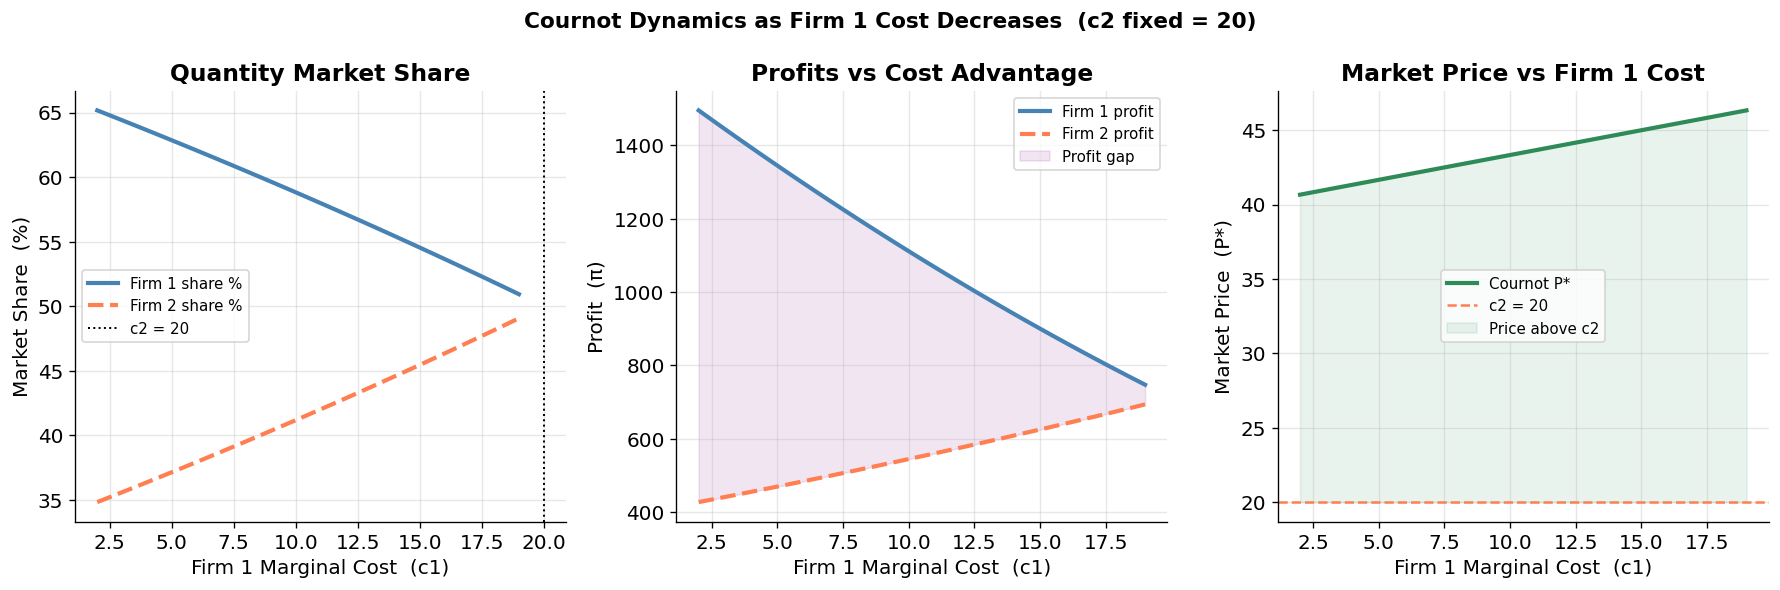

  ↑ Panel 1: Lower cost → higher market share, but never 100% under Cournot.
  ↑ Panel 2: Profit gap widens rapidly as cost advantage grows.
  ↑ Panel 3: Market price falls as efficient firm expands output.


In [ ]:
# ============================================================
# SECTION 7C: COST GAP → MARKET SHARE & PROFIT RATIO
# ============================================================

def plot_cost_gap_dynamics(a, b, base_c2=20):
    """
    Continuously vary Firm 1's cost from well-below to well-above c2.
    Show how market share and profit ratio evolve under Cournot.
    """
    c1_range = np.linspace(2, base_c2 - 1, 100)

    share1, share2   = [], []
    profit1, profit2 = [], []
    prices           = []

    for c1_ in c1_range:
        co_ = cournot_equilibrium(a, b, c1_, base_c2)
        q_total = co_['Q_star']
        share1.append(co_['q1_star']  / q_total * 100)
        share2.append(co_['q2_star']  / q_total * 100)
        profit1.append(co_['profit1'])
        profit2.append(co_['profit2'])
        prices.append(co_['P_star'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Cournot Dynamics as Firm 1 Cost Decreases  (c2 fixed = {base_c2})',
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Market share ────────────────────────────────
    ax = axes[0]
    ax.plot(c1_range, share1, color='steelblue',
            linewidth=2.5, label='Firm 1 share %')
    ax.plot(c1_range, share2, color='coral',
            linewidth=2.5, label='Firm 2 share %', linestyle='--')
    ax.axvline(base_c2, color='black', linestyle=':',
               linewidth=1.2, label=f'c2 = {base_c2}')
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Market Share  (%)')
    ax.set_title('Quantity Market Share', fontweight='bold')
    ax.legend(fontsize=9)

    # ── Panel 2: Profits ─────────────────────────────────────
    ax = axes[1]
    ax.plot(c1_range, profit1, color='steelblue',
            linewidth=2.5, label='Firm 1 profit')
    ax.plot(c1_range, profit2, color='coral',
            linewidth=2.5, label='Firm 2 profit', linestyle='--')
    ax.fill_between(c1_range, profit1, profit2,
                    alpha=0.1, color='purple', label='Profit gap')
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Profit  (π)')
    ax.set_title('Profits vs Cost Advantage', fontweight='bold')
    ax.legend(fontsize=9)

    # ── Panel 3: Market price ─────────────────────────────────
    ax = axes[2]
    ax.plot(c1_range, prices, color='seagreen',
            linewidth=2.5, label='Cournot P*')
    ax.axhline(base_c2, color='coral', linestyle='--',
               linewidth=1.5, label=f'c2 = {base_c2}')
    ax.fill_between(c1_range, prices, base_c2,
                    where=[p > base_c2 for p in prices],
                    alpha=0.1, color='seagreen', label='Price above c2')
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Market Price  (P*)')
    ax.set_title('Market Price vs Firm 1 Cost', fontweight='bold')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("  ↑ Panel 1: Lower cost → higher market share, but never 100% under Cournot.")
    print("  ↑ Panel 2: Profit gap widens rapidly as cost advantage grows.")
    print("  ↑ Panel 3: Market price falls as efficient firm expands output.")


plot_cost_gap_dynamics(a, b, base_c2=c2)

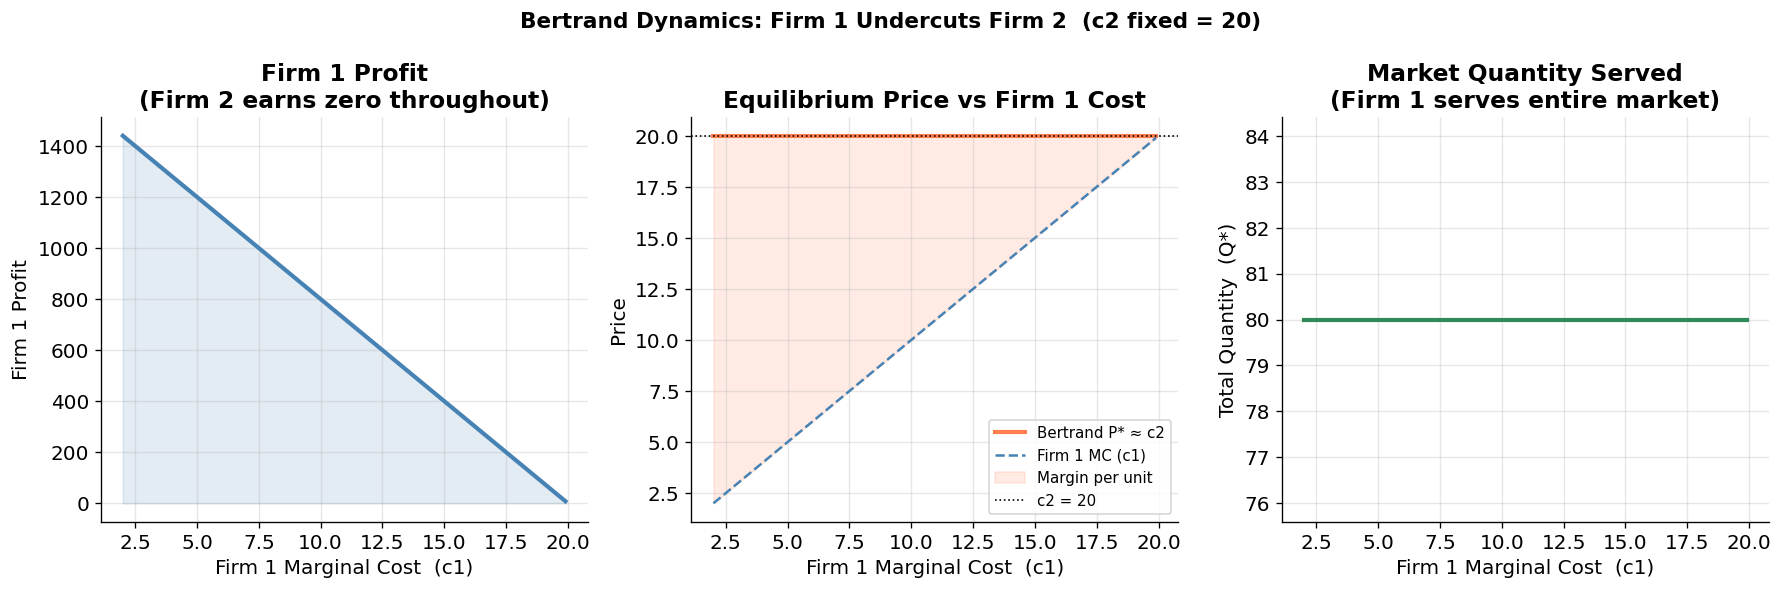

  ↑ Unlike Cournot, Bertrand produces a WINNER-TAKES-ALL outcome.
    Firm 1 sets price just below c2, captures 100% of the market,
    and earns profit = (c2 - c1) × Q — growing as cost gap widens.


In [ ]:
# ============================================================
# SECTION 7D: ASYMMETRIC BERTRAND — WINNER-TAKES-ALL DYNAMICS
# ============================================================

def plot_asymmetric_bertrand(a, b, base_c2=20):
    """
    Under Bertrand, the efficient firm wins the entire market.
    Show how Firm 1 profit evolves as its cost falls below c2.
    """
    c1_range  = np.linspace(2, base_c2 - 0.1, 100)
    be_profit = []
    be_price  = []
    be_qty    = []

    for c1_ in c1_range:
        be_ = bertrand_equilibrium(a, b, c1_, base_c2)
        be_profit.append(be_['profit1'])
        be_price.append(be_['p_star'])
        be_qty.append(be_['Q_star'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Bertrand Dynamics: Firm 1 Undercuts Firm 2  (c2 fixed = {base_c2})',
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Firm 1 profit ────────────────────────────────
    ax = axes[0]
    ax.plot(c1_range, be_profit, color='steelblue', linewidth=2.5)
    ax.fill_between(c1_range, be_profit, alpha=0.15, color='steelblue')
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Firm 1 Profit')
    ax.set_title('Firm 1 Profit\n(Firm 2 earns zero throughout)',
                 fontweight='bold')

    # ── Panel 2: Equilibrium price ───────────────────────────
    ax = axes[1]
    ax.plot(c1_range, be_price, color='coral', linewidth=2.5,
            label='Bertrand P* ≈ c2')
    ax.plot(c1_range, c1_range, color='steelblue', linewidth=1.5,
            linestyle='--', label='Firm 1 MC (c1)')
    ax.fill_between(c1_range, be_price, c1_range,
                    alpha=0.15, color='coral', label='Margin per unit')
    ax.axhline(base_c2, color='black', linestyle=':',
               linewidth=1, label=f'c2 = {base_c2}')
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Price')
    ax.set_title('Equilibrium Price vs Firm 1 Cost',
                 fontweight='bold')
    ax.legend(fontsize=9)

    # ── Panel 3: Quantity served ──────────────────────────────
    ax = axes[2]
    ax.plot(c1_range, be_qty, color='seagreen', linewidth=2.5)
    ax.set_xlabel('Firm 1 Marginal Cost  (c1)')
    ax.set_ylabel('Total Quantity  (Q*)')
    ax.set_title('Market Quantity Served\n(Firm 1 serves entire market)',
                 fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("  ↑ Unlike Cournot, Bertrand produces a WINNER-TAKES-ALL outcome.")
    print("    Firm 1 sets price just below c2, captures 100% of the market,")
    print("    and earns profit = (c2 - c1) × Q — growing as cost gap widens.")


plot_asymmetric_bertrand(a, b, base_c2=c2)

In [ ]:
# ============================================================
# SECTION 7E: FINANCE STORY — FINTECH vs INCUMBENT
# ============================================================

print("=" * 68)
print("  ASYMMETRIC COMPETITION IN FINANCE")
print("  Case Study: Fintech (Firm 1) vs Incumbent Bank (Firm 2)")
print("=" * 68)

# Fintech has lower unit cost due to technology
c1_fintech   = 10    # lower cost: no branches, automated ops
c2_incumbent = 30    # higher cost: legacy systems, branch network

co_fin = cournot_equilibrium(a, b, c1_fintech, c2_incumbent)
be_fin = bertrand_equilibrium(a, b, c1_fintech, c2_incumbent)

cs_co_fin = 0.5 * (a - co_fin['P_star']) * co_fin['Q_star']
cs_be_fin = 0.5 * (a - be_fin['p_star']) * be_fin['Q_star']

fintech_df = pd.DataFrame({
    'Metric'         : ['Price (P*)',
                        'Total Quantity (Q*)',
                        'Fintech Quantity / Share',
                        'Incumbent Quantity / Share',
                        'Fintech Profit (π₁)',
                        'Incumbent Profit (π₂)',
                        'Consumer Surplus',
                        'Market Winner'],
    'Cournot'        : [
        round(co_fin['P_star'], 2),
        round(co_fin['Q_star'], 2),
        f"{round(co_fin['q1_star'],2)}  ({round(co_fin['q1_star']/co_fin['Q_star']*100,1)}%)",
        f"{round(co_fin['q2_star'],2)}  ({round(co_fin['q2_star']/co_fin['Q_star']*100,1)}%)",
        round(co_fin['profit1'], 2),
        round(co_fin['profit2'], 2),
        round(cs_co_fin, 2),
        'Both survive'
    ],
    'Bertrand'       : [
        round(be_fin['p_star'], 2),
        round(be_fin['Q_star'], 2),
        f"{round(be_fin['Q_star'],2)}  (100%)",
        '0.0  (0%)',
        round(be_fin['profit1'], 2),
        round(be_fin['profit2'], 2),
        round(cs_be_fin, 2),
        be_fin['winner']
    ]
})

print(fintech_df.to_string(index=False))

print(f"""
  STORY:
  ──────────────────────────────────────────────────────────────
  Fintech cost (c1) = {c1_fintech}   |   Incumbent cost (c2) = {c2_incumbent}
  Cost advantage = {c2_incumbent - c1_fintech} units per loan/transaction

  Under COURNOT (volume competition):
    • Fintech takes {round(co_fin['q1_star']/co_fin['Q_star']*100,1)}% market share
    • Incumbent SURVIVES with profit = {round(co_fin['profit2'],2)}
    • Price = {round(co_fin['P_star'],2)} — both earn positive margins
    • Real-world: banks controlling mortgage/loan volumes

  Under BERTRAND (price/rate competition):
    • Fintech prices just below incumbent's MC ({c2_incumbent})
    • Incumbent is WIPED OUT — earns zero
    • Fintech captures 100% of market at price ≈ {round(be_fin['p_star'],2)}
    • Real-world: zero-fee brokers eliminating legacy commission models

  KEY LESSON FOR FINANCE:
    A fintech with even a moderate cost advantage can eliminate
    an incumbent entirely IF competition is on price.
    Incumbents survive only when competition is on volume/capacity
    — or when products are sufficiently differentiated.
""")

  ASYMMETRIC COMPETITION IN FINANCE
  Case Study: Fintech (Firm 1) vs Incumbent Bank (Firm 2)
                    Metric        Cournot            Bertrand
                Price (P*)          46.67                30.0
       Total Quantity (Q*)          53.33                70.0
  Fintech Quantity / Share 36.67  (68.8%)        70.0  (100%)
Incumbent Quantity / Share 16.67  (31.3%)           0.0  (0%)
       Fintech Profit (π₁)        1344.44              1400.0
     Incumbent Profit (π₂)         277.78                 0.0
          Consumer Surplus        1422.22              2450.0
             Market Winner   Both survive Firm 1 (lower cost)

  STORY:
  ──────────────────────────────────────────────────────────────
  Fintech cost (c1) = 10   |   Incumbent cost (c2) = 30
  Cost advantage = 20 units per loan/transaction

  Under COURNOT (volume competition):
    • Fintech takes 68.8% market share
    • Incumbent SURVIVES with profit = 277.78
    • Price = 46.67 — both earn positive mar

---
## Section 8: Optional Extensions

These extensions go beyond the core model to capture richer
real-world dynamics. Each is self-contained and clearly marked.

| Extension | Core Idea | Finance Parallel |
|---|---|---|
| **E1: Capacity Constraints** | Firms can't produce infinitely | Bank capital limits, insurer capacity |
| **E2: Product Differentiation** | Bertrand with imperfect substitutes | Banks with brand loyalty |
| **E3: Repeated Interaction** | Firms compete over many periods | Long-run rate-setting relationships |
| **E4: Welfare Analysis** | CS + PS + deadweight loss | Regulator's view of competition |

> Each extension builds directly on the baseline parameters.
> Run them independently — they don't affect earlier sections.

In [ ]:
# ============================================================
# EXTENSION 1: CAPACITY-CONSTRAINED COURNOT
# ============================================================
# Each firm has a maximum quantity it can supply (K1, K2).
# If the unconstrained optimum exceeds capacity, the firm
# produces at its cap — shifting the rival's best response.

def cournot_with_capacity(a, b, c1, c2, K1, K2):
    """
    Solve Cournot equilibrium subject to capacity constraints.

    Algorithm
    ---------
    1. Solve unconstrained Cournot
    2. If q1* > K1, fix q1 = K1 and re-solve for q2 (and vice versa)
    3. Iterate until no constraint is newly binding

    Parameters
    ----------
    K1, K2 : maximum output capacity of each firm

    Returns
    -------
    dict with constrained equilibrium values + binding flags
    """
    # Start with unconstrained solution
    co = cournot_equilibrium(a, b, c1, c2)
    q1_eq = co['q1_star']
    q2_eq = co['q2_star']

    k1_binding = False
    k2_binding = False

    # Check and apply constraints iteratively
    for _ in range(20):   # max iterations
        changed = False

        if q1_eq > K1:
            q1_eq      = K1
            k1_binding = True
            changed    = True
            # Firm 2 best-responds to capped q1
            q2_eq = best_response_2(q1_eq, a, b, c2)
            q2_eq = min(q2_eq, K2)

        if q2_eq > K2:
            q2_eq      = K2
            k2_binding = True
            changed    = True
            # Firm 1 best-responds to capped q2
            q1_eq = best_response_1(q2_eq, a, b, c1)
            q1_eq = min(q1_eq, K1)

        if not changed:
            break

    Q_eq  = q1_eq + q2_eq
    P_eq  = a - b * Q_eq
    pi1   = (P_eq - c1) * q1_eq
    pi2   = (P_eq - c2) * q2_eq

    return {
        'q1_star'     : round(q1_eq, 4),
        'q2_star'     : round(q2_eq, 4),
        'Q_star'      : round(Q_eq,  4),
        'P_star'      : round(P_eq,  4),
        'profit1'     : round(pi1,   4),
        'profit2'     : round(pi2,   4),
        'K1_binding'  : k1_binding,
        'K2_binding'  : k2_binding,
    }


# ── Test across a range of capacity limits ───────────────────
unconstrained = cournot_equilibrium(a, b, c1, c2)
q_unc = unconstrained['q1_star']   # = 26.67

capacity_scenarios = [
    ('No constraint',         100,  100),
    ('Firm 1 lightly capped',  25,  100),
    ('Firm 1 tightly capped',  15,  100),
    ('Both lightly capped',    25,   25),
    ('Both tightly capped',    15,   15),
    ('Firm 2 only capped',    100,   20),
]

cap_records = []
for label, K1, K2 in capacity_scenarios:
    r = cournot_with_capacity(a, b, c1, c2, K1, K2)
    cap_records.append({
        'Scenario'     : label,
        'K1 (cap F1)'  : K1,
        'K2 (cap F2)'  : K2,
        'q1*'          : r['q1_star'],
        'q2*'          : r['q2_star'],
        'Q*'           : r['Q_star'],
        'P*'           : r['P_star'],
        'π₁'           : r['profit1'],
        'π₂'           : r['profit2'],
        'K1 binds?'    : '✓' if r['K1_binding'] else '—',
        'K2 binds?'    : '✓' if r['K2_binding'] else '—',
    })

df_cap = pd.DataFrame(cap_records)

print("=" * 90)
print("  EXTENSION 1: CAPACITY-CONSTRAINED COURNOT EQUILIBRIUM")
print(f"  Unconstrained optimum: q1*=q2*={q_unc:.2f}  |  baseline a={a}, b={b}, c1={c1}, c2={c2}")
print("=" * 90)
print(df_cap.to_string(index=False))

print(f"""
  KEY INSIGHTS:
  • When K1 = 25 (just below unconstrained {q_unc:.1f}):
    Firm 1 is capped → Firm 2 best-responds by expanding output
    → Firm 2 gains market share and profit at Firm 1's expense

  • When both firms are tightly capped (K=15):
    Total supply falls → market price RISES above unconstrained level
    → Both firms earn higher profit per unit (scarcity rents)

  FINANCE PARALLEL:
    Bank capital requirements (Basel III) act like capacity caps.
    When one bank hits its capital limit and pulls back lending,
    rivals expand — but if ALL banks are constrained,
    credit supply falls and lending rates rise.
""")

  EXTENSION 1: CAPACITY-CONSTRAINED COURNOT EQUILIBRIUM
  Unconstrained optimum: q1*=q2*=26.67  |  baseline a=100, b=1, c1=20, c2=20
             Scenario  K1 (cap F1)  K2 (cap F2)     q1*     q2*      Q*      P*       π₁        π₂ K1 binds? K2 binds?
        No constraint          100          100 26.6667 26.6667 53.3333 46.6667 711.1111  711.1111         —         —
Firm 1 lightly capped           25          100 25.0000 27.5000 52.5000 47.5000 687.5000  756.2500         ✓         —
Firm 1 tightly capped           15          100 15.0000 32.5000 47.5000 52.5000 487.5000 1056.2500         ✓         —
  Both lightly capped           25           25 25.0000 25.0000 50.0000 50.0000 750.0000  750.0000         ✓         —
  Both tightly capped           15           15 15.0000 15.0000 30.0000 70.0000 750.0000  750.0000         ✓         —
   Firm 2 only capped          100           20 30.0000 20.0000 50.0000 50.0000 900.0000  600.0000         —         ✓

  KEY INSIGHTS:
  • When K1 = 25 

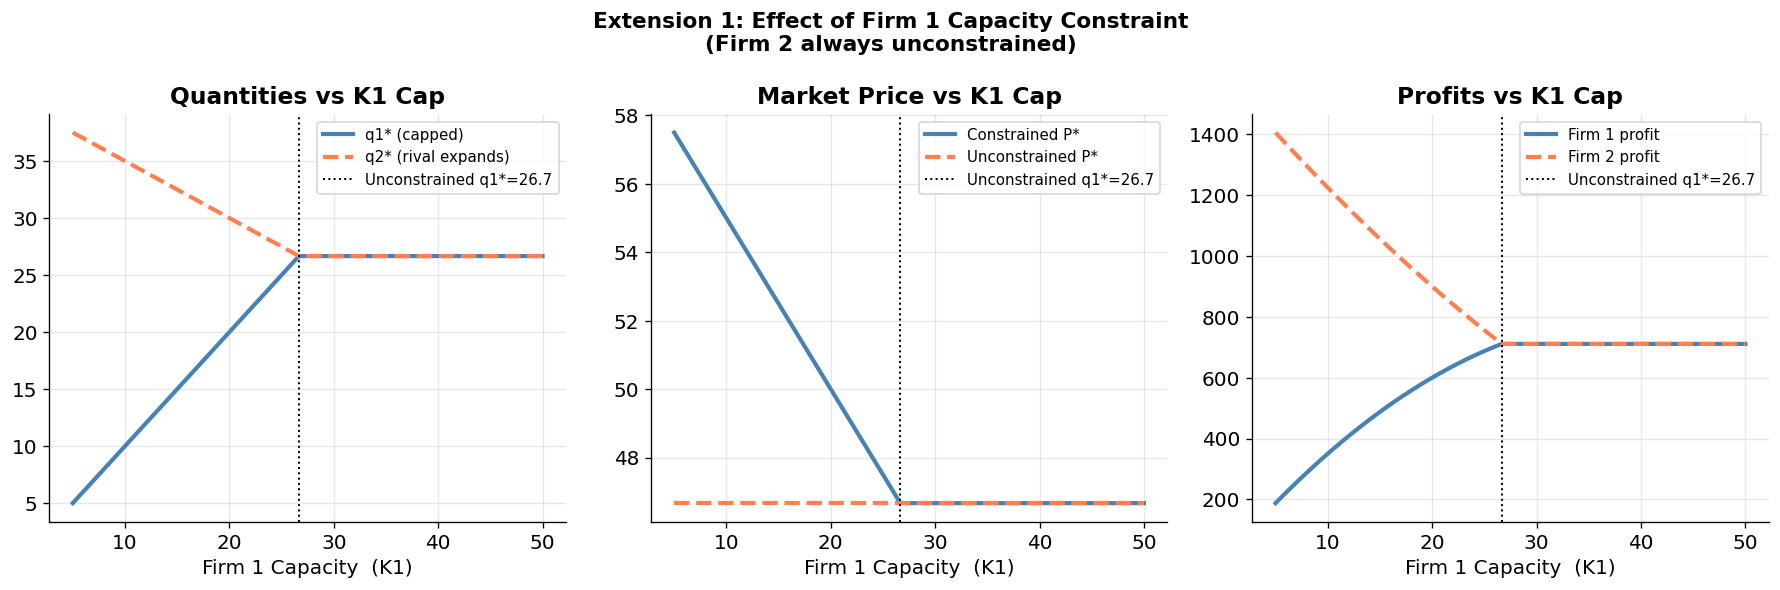

  ↑ Left of the dotted line: constraint is BINDING — Firm 1 at cap.
    Right of dotted line: constraint is slack — same as unconstrained.
    Firm 2 (coral) EXPANDS when Firm 1 is constrained — strategic substitutes.


In [ ]:
# ============================================================
# EXTENSION 1: CAPACITY CONSTRAINT — VISUALISATION
# ============================================================

def plot_capacity_effects(a, b, c1, c2):
    """
    Vary Firm 1 capacity from very tight to unconstrained.
    Show how price, Firm 2 quantity, and profits respond.
    """
    K1_range = np.linspace(5, 50, 80)
    K2_fixed = 100     # Firm 2 unconstrained

    prices, q1s, q2s, pi1s, pi2s = [], [], [], [], []

    for K1 in K1_range:
        r = cournot_with_capacity(a, b, c1, c2, K1, K2_fixed)
        prices.append(r['P_star'])
        q1s.append(r['q1_star'])
        q2s.append(r['q2_star'])
        pi1s.append(r['profit1'])
        pi2s.append(r['profit2'])

    # Unconstrained benchmark
    unc = cournot_equilibrium(a, b, c1, c2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Extension 1: Effect of Firm 1 Capacity Constraint\n'
                 '(Firm 2 always unconstrained)',
                 fontsize=13, fontweight='bold')

    for ax, y1, y2, title, lab1, lab2 in [
        (axes[0], q1s,  q2s,  'Quantities vs K1 Cap',
         'q1* (capped)', 'q2* (rival expands)'),
        (axes[1], prices, [unc['P_star']]*len(K1_range),
         'Market Price vs K1 Cap',
         'Constrained P*', 'Unconstrained P*'),
        (axes[2], pi1s, pi2s,
         'Profits vs K1 Cap',
         'Firm 1 profit', 'Firm 2 profit'),
    ]:
        ax.plot(K1_range, y1, color='steelblue',
                linewidth=2.5, label=lab1)
        ax.plot(K1_range, y2, color='coral',
                linewidth=2.5, linestyle='--', label=lab2)
        ax.axvline(unc['q1_star'], color='black', linestyle=':',
                   linewidth=1.2, label=f"Unconstrained q1*={unc['q1_star']:.1f}")
        ax.set_xlabel('Firm 1 Capacity  (K1)')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("  ↑ Left of the dotted line: constraint is BINDING — Firm 1 at cap.")
    print("    Right of dotted line: constraint is slack — same as unconstrained.")
    print("    Firm 2 (coral) EXPANDS when Firm 1 is constrained — strategic substitutes.")


plot_capacity_effects(a, b, c1, c2)

In [ ]:
# ============================================================
# EXTENSION 2: BERTRAND WITH PRODUCT DIFFERENTIATION
# ============================================================
# When products are imperfect substitutes, a firm cutting price
# doesn't capture 100% of the rival's demand.
# Each firm faces its own downward-sloping demand curve.
#
# Demand system (Shubik-Levitan / differentiated Bertrand):
#   q1 = a - p1 + gamma * p2
#   q2 = a - p2 + gamma * p1
#
# gamma in [0, 1]:
#   gamma = 0  → monopolists (no competition)
#   gamma = 1  → perfect substitutes (standard Bertrand)

from sympy import symbols as sym, solve as sym_solve, diff as sym_diff

def differentiated_bertrand(a, c1, c2, gamma):
    """
    Solve Bertrand equilibrium with differentiated products.

    Parameters
    ----------
    gamma : substitutability parameter (0 = independent, 1 = homogeneous)

    Returns
    -------
    dict with equilibrium prices, quantities, profits
    """
    p1_s, p2_s = sym('p1 p2', positive=True)

    # Demand functions
    q1_s = a - p1_s + gamma * p2_s
    q2_s = a - p2_s + gamma * p1_s

    # Profit functions
    pi1_s = (p1_s - c1) * q1_s
    pi2_s = (p2_s - c2) * q2_s

    # First-order conditions
    foc1_s = sym_diff(pi1_s, p1_s)
    foc2_s = sym_diff(pi2_s, p2_s)

    # Solve simultaneously
    sol = sym_solve([foc1_s, foc2_s], [p1_s, p2_s])

    p1_eq = float(sol[p1_s])
    p2_eq = float(sol[p2_s])
    q1_eq = float(q1_s.subs([(p1_s, p1_eq), (p2_s, p2_eq)]))
    q2_eq = float(q2_s.subs([(p1_s, p1_eq), (p2_s, p2_eq)]))
    pi1_eq = (p1_eq - c1) * q1_eq
    pi2_eq = (p2_eq - c2) * q2_eq

    return {
        'gamma'   : gamma,
        'p1_star' : round(p1_eq,  4),
        'p2_star' : round(p2_eq,  4),
        'q1_star' : round(max(q1_eq, 0), 4),
        'q2_star' : round(max(q2_eq, 0), 4),
        'profit1' : round(pi1_eq, 4),
        'profit2' : round(pi2_eq, 4),
    }


# ── Sweep gamma from 0.1 to 0.95 ─────────────────────────────
gamma_vals = np.linspace(0.05, 0.95, 40)
diff_records = []

for g in gamma_vals:
    try:
        r = differentiated_bertrand(a, c1, c2, g)
        diff_records.append(r)
    except Exception:
        continue

df_diff = pd.DataFrame(diff_records)

# ── Print selected values ────────────────────────────────────
print("=" * 65)
print("  EXTENSION 2: DIFFERENTIATED BERTRAND EQUILIBRIUM")
print(f"  (a={a}, c1={c1}, c2={c2})")
print("=" * 65)
preview = df_diff.iloc[::8][['gamma','p1_star','q1_star','profit1']]
preview.columns = ['γ (substitutability)', 'Price p1*',
                   'Quantity q1*', 'Profit π₁']
print(preview.to_string(index=False))
print(f"""
  INTERPRETATION:
  • γ → 0: firms behave like monopolists — high prices, high profits
  • γ → 1: approaches Bertrand paradox — prices fall toward MC
  • At γ = 0.5 (moderate differentiation):
    p1* = {df_diff.loc[df_diff['gamma'].sub(0.5).abs().idxmin(), 'p1_star']:.2f}
    (above MC = {c1}, below monopoly = {(a+c1)/2:.2f})

  FINANCE PARALLEL:
    Two banks offering slightly different mortgage products
    (different terms, service quality, brand loyalty) are
    differentiated Bertrand competitors — they keep prices
    above MC even with direct competition.
""")

  EXTENSION 2: DIFFERENTIATED BERTRAND EQUILIBRIUM
  (a=100, c1=20, c2=20)
 γ (substitutability)  Price p1*  Quantity q1*  Profit π₁
             0.050000    61.5385       41.5385  1725.4438
             0.234615    67.9739       47.9739  2301.4909
             0.419231    75.9124       55.9124  3126.1975
             0.603846    85.9504       65.9504  4349.4570
             0.788462    99.0476       79.0476  6248.5261

  INTERPRETATION:
  • γ → 0: firms behave like monopolists — high prices, high profits
  • γ → 1: approaches Bertrand paradox — prices fall toward MC
  • At γ = 0.5 (moderate differentiation):
    p1* = 80.62
    (above MC = 20, below monopoly = 60.00)

  FINANCE PARALLEL:
    Two banks offering slightly different mortgage products
    (different terms, service quality, brand loyalty) are
    differentiated Bertrand competitors — they keep prices
    above MC even with direct competition.



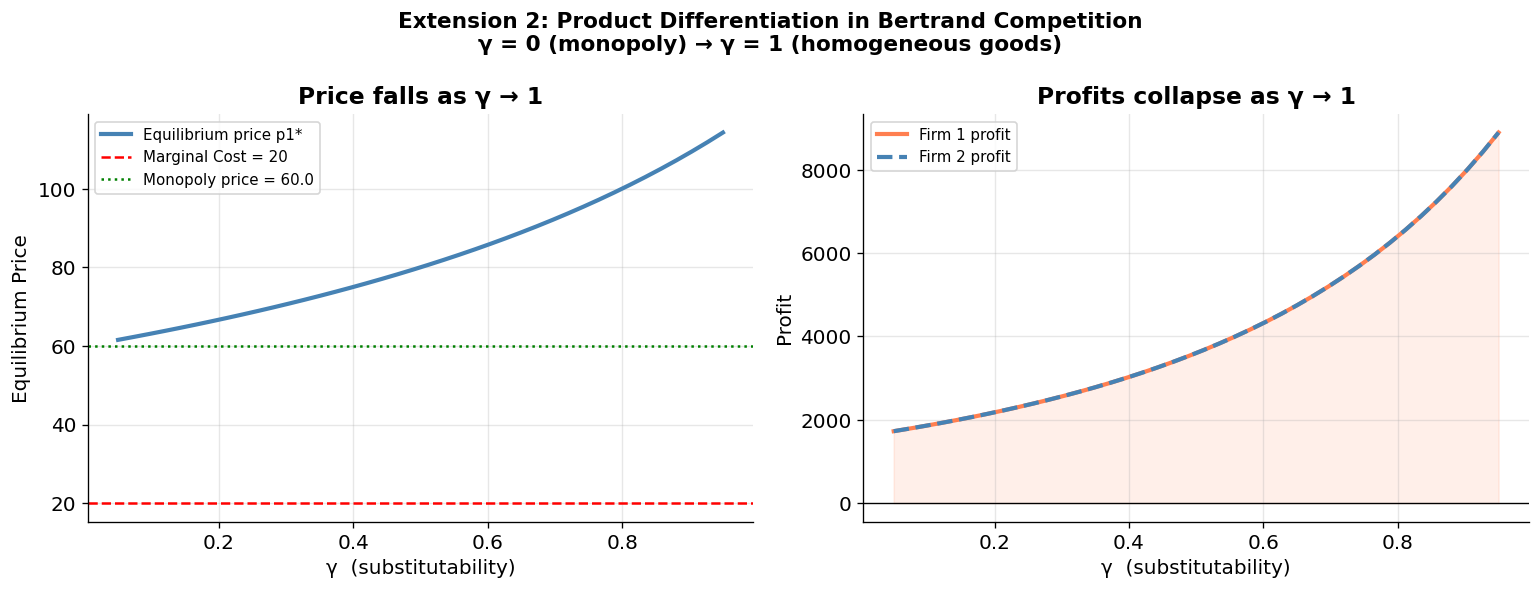

  ↑ Key result: even SLIGHT differentiation (γ < 1) preserves positive profit.
    This is why banks, brokers, and insurers invest heavily in brand and
    product features — differentiation is the escape from the Bertrand trap.


In [ ]:
# ============================================================
# EXTENSION 2: DIFFERENTIATION — VISUALISATION
# ============================================================

def plot_differentiation_effects(df_diff, c1, a):
    """
    Show how increasing product substitutability (gamma)
    drives prices and profits toward the Bertrand floor.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Extension 2: Product Differentiation in Bertrand Competition\n'
                 'γ = 0 (monopoly) → γ = 1 (homogeneous goods)',
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Price vs gamma ───────────────────────────────
    ax = axes[0]
    ax.plot(df_diff['gamma'], df_diff['p1_star'],
            color='steelblue', linewidth=2.5, label='Equilibrium price p1*')
    ax.axhline(c1, color='red', linestyle='--',
               linewidth=1.5, label=f'Marginal Cost = {c1}')
    ax.axhline((a + c1) / 2, color='green', linestyle=':',
               linewidth=1.5, label=f'Monopoly price = {(a+c1)/2:.1f}')
    ax.set_xlabel('γ  (substitutability)')
    ax.set_ylabel('Equilibrium Price')
    ax.set_title('Price falls as γ → 1', fontweight='bold')
    ax.legend(fontsize=9)

    # ── Panel 2: Profit vs gamma ──────────────────────────────
    ax = axes[1]
    ax.plot(df_diff['gamma'], df_diff['profit1'],
            color='coral', linewidth=2.5, label='Firm 1 profit')
    ax.plot(df_diff['gamma'], df_diff['profit2'],
            color='steelblue', linewidth=2.5, linestyle='--',
            label='Firm 2 profit')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(df_diff['gamma'], df_diff['profit1'],
                    alpha=0.12, color='coral')
    ax.set_xlabel('γ  (substitutability)')
    ax.set_ylabel('Profit')
    ax.set_title('Profits collapse as γ → 1', fontweight='bold')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("  ↑ Key result: even SLIGHT differentiation (γ < 1) preserves positive profit.")
    print("    This is why banks, brokers, and insurers invest heavily in brand and")
    print("    product features — differentiation is the escape from the Bertrand trap.")


plot_differentiation_effects(df_diff, c1, a)

In [ ]:
# ============================================================
# EXTENSION 3: REPEATED COURNOT COMPETITION
# ============================================================
# Firms interact over T periods. Each period they observe the
# previous outcome and adjust strategy.
#
# Three strategy types:
#   'static'   → always play one-shot Nash (no learning)
#   'collusive'→ both restrict output to maximise joint profit
#   'adaptive' → best-respond to rival's LAST period quantity

def monopoly_quantity(a, b, c):
    """Joint profit-maximising (collusive) quantity per firm."""
    q_mono = (a - c) / (2 * b)
    return q_mono / 2          # split equally between two firms


def run_repeated_cournot(a, b, c1, c2, T=30, strategy='adaptive',
                          q1_init=None, q2_init=None):
    """
    Simulate T periods of repeated Cournot competition.

    Strategies
    ----------
    'static'   : both play Nash every period
    'collusive': both play joint-profit-max quantity
    'adaptive' : each firm best-responds to rival's last quantity

    Returns
    -------
    DataFrame with period-by-period outcomes
    """
    co_nash  = cournot_equilibrium(a, b, c1, c2)
    q_col    = monopoly_quantity(a, b, (c1 + c2) / 2)

    # Starting quantities
    q1 = q1_init if q1_init else co_nash['q1_star'] * 1.3
    q2 = q2_init if q2_init else co_nash['q2_star'] * 0.7

    history = []

    for t in range(T):

        if strategy == 'static':
            q1 = co_nash['q1_star']
            q2 = co_nash['q2_star']

        elif strategy == 'collusive':
            q1 = q_col
            q2 = q_col

        elif strategy == 'adaptive':
            # Each firm best-responds to rival's previous quantity
            q1_new = best_response_1(q2, a, b, c1)
            q2_new = best_response_2(q1, a, b, c2)
            q1, q2 = q1_new, q2_new

        Q   = q1 + q2
        P   = a - b * Q
        pi1 = (P - c1) * q1
        pi2 = (P - c2) * q2

        history.append({
            'Period'   : t + 1,
            'q1'       : round(q1,  4),
            'q2'       : round(q2,  4),
            'Q'        : round(Q,   4),
            'Price'    : round(P,   4),
            'Profit_1' : round(pi1, 4),
            'Profit_2' : round(pi2, 4),
            'Strategy' : strategy,
        })

    return pd.DataFrame(history)


# ── Run all three strategies ─────────────────────────────────
T = 25
df_static    = run_repeated_cournot(a, b, c1, c2, T, 'static')
df_collusive = run_repeated_cournot(a, b, c1, c2, T, 'collusive')
df_adaptive  = run_repeated_cournot(a, b, c1, c2, T, 'adaptive')

print("  Adaptive strategy — first 8 periods:")
print(df_adaptive[['Period','q1','q2','Price','Profit_1']
                  ].head(8).to_string(index=False))
print(f"\n  Converges to Nash: q1*={round(cournot_equilibrium(a,b,c1,c2)['q1_star'],2)}")

  Adaptive strategy — first 8 periods:
 Period      q1      q2   Price  Profit_1
      1 30.6667 22.6667 46.6667  817.7778
      2 28.6667 24.6667 46.6667  764.4444
      3 27.6667 25.6667 46.6667  737.7778
      4 27.1667 26.1667 46.6667  724.4444
      5 26.9167 26.4167 46.6667  717.7778
      6 26.7917 26.5417 46.6667  714.4444
      7 26.7292 26.6042 46.6667  712.7778
      8 26.6979 26.6354 46.6667  711.9444

  Converges to Nash: q1*=26.67


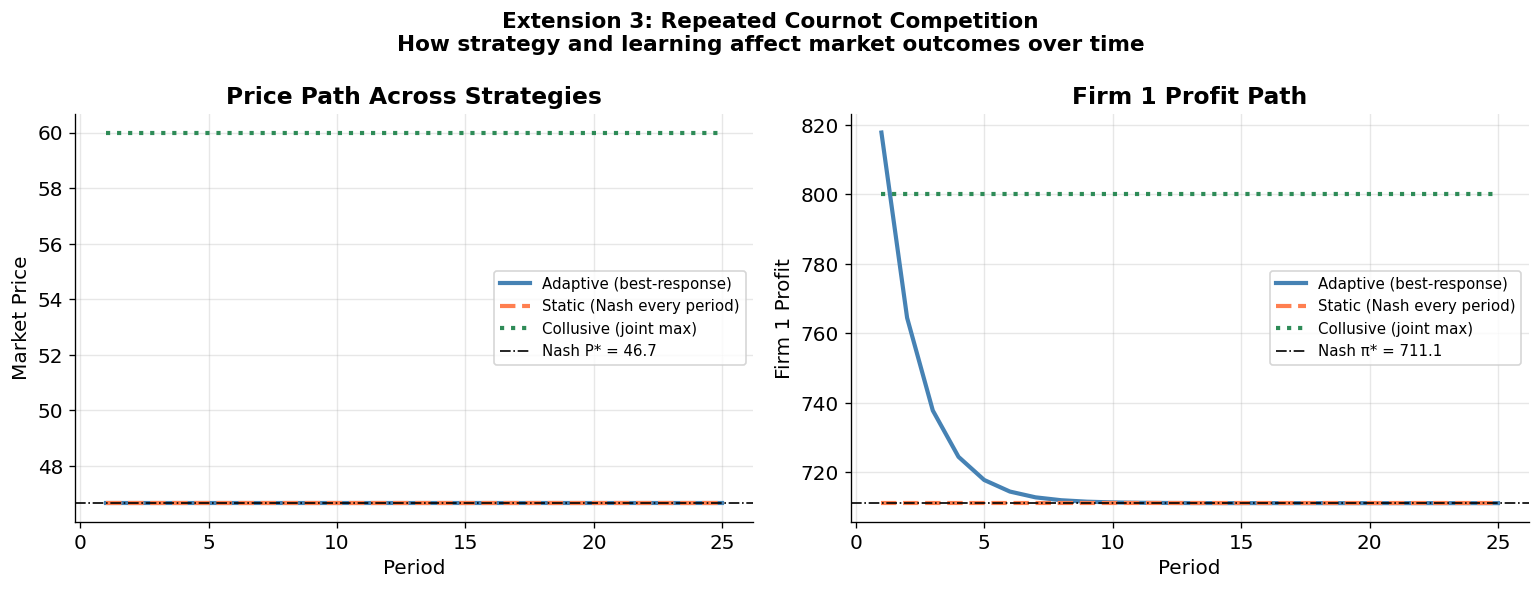

  ↑ Adaptive path converges to Nash equilibrium within ~10 periods.
    Collusive path yields higher profits — but requires coordination.
    In finance: repeated lending or fee-setting relationships may
    sustain tacit collusion above the one-shot Nash outcome.


In [ ]:
# ============================================================
# EXTENSION 3: REPEATED COURNOT — VISUALISATION
# ============================================================

def plot_repeated_cournot(df_static, df_collusive, df_adaptive, a, b, c1, c2):
    """
    Compare price and profit paths across three strategies
    over T periods of repeated competition.
    """
    co_nash = cournot_equilibrium(a, b, c1, c2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Extension 3: Repeated Cournot Competition\n'
                 'How strategy and learning affect market outcomes over time',
                 fontsize=13, fontweight='bold')

    for ax, metric, ylabel, title in [
        (axes[0], 'Price',    'Market Price',    'Price Path Across Strategies'),
        (axes[1], 'Profit_1', 'Firm 1 Profit',   'Firm 1 Profit Path'),
    ]:
        for df, label, color, ls in [
            (df_adaptive,  'Adaptive (best-response)', 'steelblue', '-'),
            (df_static,    'Static (Nash every period)', 'coral',   '--'),
            (df_collusive, 'Collusive (joint max)',     'seagreen',  ':'),
        ]:
            ax.plot(df['Period'], df[metric],
                    label=label, color=color,
                    linestyle=ls, linewidth=2.5)

        # Nash benchmark line
        if metric == 'Price':
            ax.axhline(co_nash['P_star'], color='black',
                       linestyle='-.', linewidth=1,
                       label=f"Nash P* = {co_nash['P_star']:.1f}")
        else:
            ax.axhline(co_nash['profit1'], color='black',
                       linestyle='-.', linewidth=1,
                       label=f"Nash π* = {co_nash['profit1']:.1f}")

        ax.set_xlabel('Period')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("  ↑ Adaptive path converges to Nash equilibrium within ~10 periods.")
    print("    Collusive path yields higher profits — but requires coordination.")
    print("    In finance: repeated lending or fee-setting relationships may")
    print("    sustain tacit collusion above the one-shot Nash outcome.")


plot_repeated_cournot(df_static, df_collusive, df_adaptive, a, b, c1, c2)

In [ ]:
# ============================================================
# EXTENSION 4: WELFARE ANALYSIS
# ============================================================
# Compare Cournot, Bertrand, Monopoly, and Perfect Competition
# on Consumer Surplus, Producer Surplus, and Deadweight Loss.

def welfare_analysis(a, b, c1, c2):
    """
    Compute full welfare breakdown for four market structures:
    Monopoly | Cournot | Bertrand | Perfect Competition

    Returns
    -------
    DataFrame with CS, PS, DWL, Total Welfare for each structure
    """
    c = (c1 + c2) / 2    # average MC for symmetric comparison

    # ── 1. Perfect Competition: P = MC ───────────────────────
    P_pc  = c
    Q_pc  = a - b * P_pc
    CS_pc = 0.5 * (a - P_pc) * Q_pc
    PS_pc = 0.0                          # zero profit
    TW_pc = CS_pc + PS_pc

    # ── 2. Monopoly: MR = MC ─────────────────────────────────
    P_mon  = (a + c) / 2
    Q_mon  = (a - c) / (2 * b)
    CS_mon = 0.5 * (a - P_mon) * Q_mon
    PS_mon = (P_mon - c) * Q_mon
    TW_mon = CS_mon + PS_mon

    # ── 3. Cournot duopoly ────────────────────────────────────
    co     = cournot_equilibrium(a, b, c1, c2)
    CS_co  = 0.5 * (a - co['P_star']) * co['Q_star']
    PS_co  = co['total_profit']
    TW_co  = CS_co + PS_co

    # ── 4. Bertrand duopoly ───────────────────────────────────
    be     = bertrand_equilibrium(a, b, c1, c2)
    CS_be  = 0.5 * (a - be['p_star']) * be['Q_star']
    PS_be  = be['total_profit']
    TW_be  = CS_be + PS_be

    # ── Deadweight Loss = TW_perfect_competition − TW_actual ─
    def dwl(tw): return round(TW_pc - tw, 2)

    results = pd.DataFrame({
        'Market Structure' : ['Perfect Competition',
                              'Bertrand Duopoly',
                              'Cournot Duopoly',
                              'Monopoly'],
        'Price'            : [round(P_pc,   2), round(be['p_star'], 2),
                              round(co['P_star'], 2), round(P_mon, 2)],
        'Quantity'         : [round(Q_pc,   2), round(be['Q_star'], 2),
                              round(co['Q_star'], 2), round(Q_mon, 2)],
        'Consumer Surplus' : [round(CS_pc,  2), round(CS_be, 2),
                              round(CS_co, 2),  round(CS_mon, 2)],
        'Producer Surplus' : [round(PS_pc,  2), round(PS_be, 2),
                              round(PS_co, 2),  round(PS_mon, 2)],
        'Total Welfare'    : [round(TW_pc,  2), round(TW_be, 2),
                              round(TW_co, 2),  round(TW_mon, 2)],
        'Deadweight Loss'  : [dwl(TW_pc),       dwl(TW_be),
                              dwl(TW_co),        dwl(TW_mon)],
    })

    return results


df_welfare = welfare_analysis(a, b, c1, c2)

print("=" * 80)
print("  EXTENSION 4: WELFARE ANALYSIS ACROSS MARKET STRUCTURES")
print(f"  (a={a}, b={b}, c1={c1}, c2={c2})")
print("=" * 80)
print(df_welfare.to_string(index=False))
print(f"""
  WELFARE RANKING (best → worst for society):
  Perfect Competition = Bertrand > Cournot > Monopoly

  Deadweight loss under Cournot:  {df_welfare.loc[df_welfare['Market Structure']=='Cournot Duopoly','Deadweight Loss'].values[0]}
  Deadweight loss under Monopoly: {df_welfare.loc[df_welfare['Market Structure']=='Monopoly','Deadweight Loss'].values[0]}

  REGULATOR'S VIEW:
    Bertrand (price competition) is socially optimal —
    it replicates perfect competition.
    Cournot (quantity competition) creates a moderate
    deadweight loss — output is restricted, price is above MC.
    Monopoly produces the worst outcome — maximum DWL.
""")

  EXTENSION 4: WELFARE ANALYSIS ACROSS MARKET STRUCTURES
  (a=100, b=1, c1=20, c2=20)
   Market Structure  Price  Quantity  Consumer Surplus  Producer Surplus  Total Welfare  Deadweight Loss
Perfect Competition  20.00     80.00           3200.00              0.00        3200.00             0.00
   Bertrand Duopoly  20.00     80.00           3200.00              0.00        3200.00             0.00
    Cournot Duopoly  46.67     53.33           1422.22           1422.22        2844.44           355.56
           Monopoly  60.00     40.00            800.00           1600.00        2400.00           800.00

  WELFARE RANKING (best → worst for society):
  Perfect Competition = Bertrand > Cournot > Monopoly

  Deadweight loss under Cournot:  355.56
  Deadweight loss under Monopoly: 800.0

  REGULATOR'S VIEW:
    Bertrand (price competition) is socially optimal —
    it replicates perfect competition.
    Cournot (quantity competition) creates a moderate
    deadweight loss — output is restr

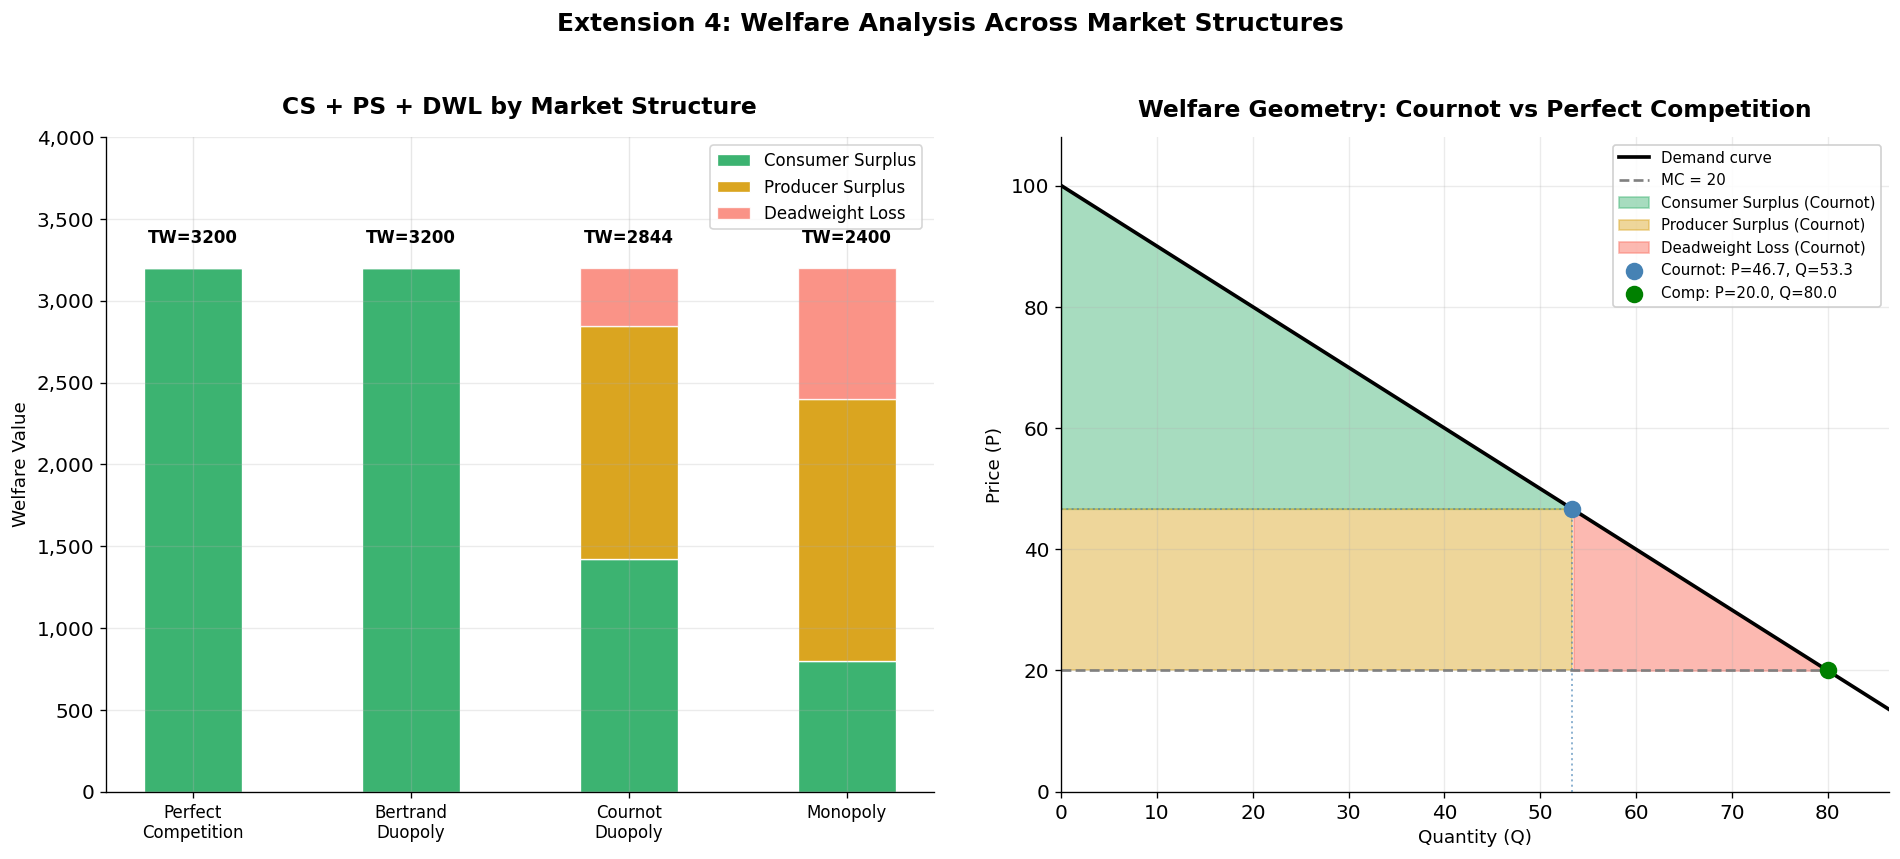

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ============================================================
# EXTENSION 4: WELFARE — STACKED BAR + DEMAND CURVE PLOTS
# ============================================================

def plot_welfare(df_welfare, a, b, c1, c2):

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(
        'Extension 4: Welfare Analysis Across Market Structures',
        fontsize=15, fontweight='bold', y=1.02
    )

    # ── Panel 1: Stacked bar chart ────────────────────────────
    ax = axes[0]

    cs_vals  = df_welfare['Consumer Surplus'].values
    ps_vals  = df_welfare['Producer Surplus'].values
    dwl_vals = df_welfare['Deadweight Loss'].values
    x = np.arange(len(df_welfare))
    bar_w = 0.45

    ax.bar(
        x, cs_vals, bar_w,
        label='Consumer Surplus',
        color='mediumseagreen',
        edgecolor='white',
        linewidth=0.8
    )

    ax.bar(
        x, ps_vals, bar_w,
        bottom=cs_vals,
        label='Producer Surplus',
        color='goldenrod',
        edgecolor='white',
        linewidth=0.8
    )

    ax.bar(
        x, dwl_vals, bar_w,
        bottom=cs_vals + ps_vals,
        label='Deadweight Loss',
        color='salmon',
        edgecolor='white',
        linewidth=0.8,
        alpha=0.85
    )

    total_stack = cs_vals + ps_vals + dwl_vals
    max_stack = total_stack.max()
    label_offset = max_stack * 0.04

    for i, row in df_welfare.iterrows():
        stack_top = (
            row['Consumer Surplus']
            + row['Producer Surplus']
            + row['Deadweight Loss']
        )

        ax.text(
            i,
            stack_top + label_offset,
            f"TW={row['Total Welfare']:.0f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Perfect\nCompetition', 'Bertrand\nDuopoly',
         'Cournot\nDuopoly', 'Monopoly'],
        fontsize=10
    )
    ax.set_ylabel('Welfare Value', fontsize=11)
    ax.set_title('CS + PS + DWL by Market Structure', fontweight='bold', pad=14)
    ax.set_ylim(0, max_stack * 1.25)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'{val:,.0f}')
    )

    # Move legend so it does not cover labels
    ax.legend(loc='upper left', bbox_to_anchor=(0.72, 1.0), fontsize=10)
    ax.grid(axis='y', alpha=0.25)

    # ── Panel 2: Demand curve geometry ───────────────────────
    ax = axes[1]

    c = (c1 + c2) / 2
    co = cournot_equilibrium(a, b, c1, c2)

    P_co = co['P_star']
    Q_co = co['Q_star']
    P_pc = c
    Q_pc = a - b * P_pc

    q_range = np.linspace(0, Q_pc * 1.08, 400)
    P_curve = a - b * q_range

    ax.plot(q_range, P_curve, color='black', linewidth=2.2, label='Demand curve')

    ax.hlines(
        c, 0, Q_pc,
        colors='gray',
        linestyles='--',
        linewidth=1.6,
        label=f'MC = {c:.0f}'
    )

    ax.fill_between(
        q_range, P_curve, P_co,
        where=(q_range <= Q_co),
        color='mediumseagreen',
        alpha=0.45,
        label='Consumer Surplus (Cournot)'
    )

    ax.fill_between(
        [0, Q_co], [P_co, P_co], [c, c],
        color='goldenrod',
        alpha=0.45,
        label='Producer Surplus (Cournot)'
    )

    ax.fill_between(
        q_range, P_curve, c,
        where=(q_range >= Q_co) & (q_range <= Q_pc),
        color='salmon',
        alpha=0.55,
        label='Deadweight Loss (Cournot)'
    )

    ax.scatter(
        [Q_co], [P_co],
        color='steelblue', s=90, zorder=6,
        label=f'Cournot: P={P_co:.1f}, Q={Q_co:.1f}'
    )

    ax.scatter(
        [Q_pc], [P_pc],
        color='green', s=90, zorder=6,
        label=f'Comp: P={P_pc:.1f}, Q={Q_pc:.1f}'
    )

    ax.plot([Q_co, Q_co], [0, P_co], color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6)
    ax.plot([0, Q_co], [P_co, P_co], color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6)

    ax.set_xlabel('Quantity (Q)', fontsize=11)
    ax.set_ylabel('Price (P)', fontsize=11)
    ax.set_title('Welfare Geometry: Cournot vs Perfect Competition', fontweight='bold', pad=12)
    ax.set_xlim(0, Q_pc * 1.08)
    ax.set_ylim(0, a * 1.08)
    ax.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='#cccccc')
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# call the function
plot_welfare(df_welfare, a, b, c1, c2)

In [ ]:
# ============================================================
# SECTION 9: EXPORT ALL VISUALISATIONS
# ============================================================
# Saves every chart to:
#   1. Individual high-res PNGs  (one per chart)
#   2. A single combined PDF     (all charts, one file to download)
# In Google Colab — files appear in the Files panel (left sidebar)

import os
from matplotlib.backends.backend_pdf import PdfPages

# ── Output folder ────────────────────────────────────────────
OUT_DIR = "oligopoly_charts"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Helper: save one figure ───────────────────────────────────
def save_fig(fig, filename):
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f"  ✓  saved  →  {path}")
    return fig

# ============================================================
# RE-DRAW EVERY CHART INTO A NAMED FIGURE
# (same functions as before, just captured into fig objects)
# ============================================================

all_figures = []        # collect in order for the PDF

# ── 1. Cournot best response curves ─────────────────────────
def fig_best_responses(a, b, c1, c2, cournot_eq):
    q_max   = (a - min(c1, c2)) / b
    q_range = np.linspace(0, q_max * 0.8, 300)
    br1_vals = [best_response_1(q, a, b, c1) for q in q_range]
    br2_vals = [best_response_2(q, a, b, c2) for q in q_range]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(br1_vals, q_range,  color='steelblue', linewidth=2.5,
            label='BR₁(q₂) — Firm 1')
    ax.plot(q_range,  br2_vals, color='coral',     linewidth=2.5,
            label='BR₂(q₁) — Firm 2')
    ax.scatter(cournot_eq['q1_star'], cournot_eq['q2_star'],
               s=150, zorder=5, color='darkgreen',
               label=f"Nash Eq: ({cournot_eq['q1_star']:.1f}, {cournot_eq['q2_star']:.1f})")
    ax.plot([cournot_eq['q1_star']]*2, [0, cournot_eq['q2_star']],
            'k--', alpha=0.4, linewidth=1)
    ax.plot([0, cournot_eq['q1_star']], [cournot_eq['q2_star']]*2,
            'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel('q₁  (Firm 1 quantity)')
    ax.set_ylabel('q₂  (Firm 2 quantity)')
    ax.set_title('Cournot Best Response Curves\n(Intersection = Nash Equilibrium)',
                 fontweight='bold')
    ax.legend(); ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    plt.tight_layout()
    return fig

fig1 = fig_best_responses(a, b, c1, c2, co)
save_fig(fig1, "01_cournot_best_response.png")
all_figures.append(('Cournot Best Response Curves', fig1))
plt.close(fig1)


# ── 2. Bertrand heatmaps ─────────────────────────────────────
def fig_bertrand_heatmaps(a, b, c1, c2):
    prices, grid1, grid2 = simulate_bertrand_grid(a, b, c1, c2)
    tick_labels = [f"{p:.0f}" for p in prices]
    step = len(prices) // 6

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, grid, label, cmap in zip(
            axes, [grid1, grid2], ['Firm 1', 'Firm 2'], ['Blues','Oranges']):
        im = ax.imshow(grid, origin='lower', aspect='auto',
                       cmap=cmap, interpolation='nearest')
        plt.colorbar(im, ax=ax, label='Profit')
        ax.set_xticks(range(0, len(prices), step))
        ax.set_xticklabels(tick_labels[::step], rotation=45)
        ax.set_yticks(range(0, len(prices), step))
        ax.set_yticklabels(tick_labels[::step])
        ax.set_xlabel('p₂'); ax.set_ylabel('p₁')
        ax.set_title(f'{label} Profit Heatmap', fontweight='bold')
        ax.scatter(0, 0, color='red', s=100, zorder=5,
                   label='Bertrand Eq'); ax.legend(fontsize=9)
    fig.suptitle('Bertrand Competition — Profit Heatmaps',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

fig2 = fig_bertrand_heatmaps(a, b, c1, c2)
save_fig(fig2, "02_bertrand_heatmaps.png")
all_figures.append(('Bertrand Profit Heatmaps', fig2))
plt.close(fig2)


# ── 3. Bertrand undercutting dynamics ────────────────────────
def fig_undercutting(a, b, c1, c2):
    p_mono  = (a + c1) / 2
    p1_vals = np.linspace(c1, p_mono * 1.05, 400)
    fixed   = {'p₂=40': 40, 'p₂=60': 60, 'p₂=80': 80}
    colors  = ['steelblue', 'coral', 'seagreen']

    fig, ax = plt.subplots(figsize=(10, 6))
    for (lbl, p2f), col in zip(fixed.items(), colors):
        profits = [bertrand_profits(p1, p2f, a, b, c1, c2)[0]
                   for p1 in p1_vals]
        ax.plot(p1_vals, profits, label=lbl, color=col, linewidth=2)
        ax.axvline(p2f, color=col, linestyle='--', alpha=0.4, linewidth=1)
    ax.axvline(c1, color='black', linestyle=':', linewidth=1.5,
               label=f'MC = {c1}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('p₁  (Firm 1 price)'); ax.set_ylabel('Firm 1 Profit')
    ax.set_title("Firm 1's Profit vs Its Own Price\n"
                 "(Undercutting Dynamics)", fontweight='bold')
    ax.legend(); plt.tight_layout()
    return fig

fig3 = fig_undercutting(a, b, c1, c2)
save_fig(fig3, "03_bertrand_undercutting.png")
all_figures.append(('Bertrand Undercutting Dynamics', fig3))
plt.close(fig3)


# ── 4. Cournot vs Bertrand comparison bars ───────────────────
def fig_comparison(co, be, cs_co, cs_be, tw_co, tw_be, c1):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle('Cournot vs Bertrand — Key Metrics Compared',
                 fontsize=15, fontweight='bold')
    models = ['Cournot', 'Bertrand']
    colors = ['steelblue', 'coral']

    ax = axes[0,0]
    bars = ax.bar(models, [co['P_star'], be['p_star']],
                  color=colors, width=0.5, edgecolor='white')
    ax.axhline(c1, color='black', linestyle='--', linewidth=1.5,
               label=f'MC = {c1}')
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)
    ax.set_title('Market Price (P*)', fontweight='bold')
    ax.set_ylabel('Price'); ax.legend()
    ax.set_ylim(0, max(co['P_star'], be['p_star']) * 1.25)

    ax = axes[0,1]
    bars = ax.bar(models, [co['Q_star'], be['Q_star']],
                  color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)
    ax.set_title('Total Market Quantity (Q*)', fontweight='bold')
    ax.set_ylabel('Quantity')
    ax.set_ylim(0, max(co['Q_star'], be['Q_star']) * 1.25)

    ax = axes[1,0]
    x = np.arange(2); w = 0.32
    b1 = ax.bar(x-w/2, [co['profit1'], be['profit1']],
                w, label='Firm 1', color='steelblue', edgecolor='white')
    b2 = ax.bar(x+w/2, [co['profit2'], be['profit2']],
                w, label='Firm 2', color='coral',     edgecolor='white')
    ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=10)
    ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title('Firm Profits (π₁*, π₂*)', fontweight='bold')
    ax.set_ylabel('Profit'); ax.legend()
    ax.set_ylim(0, max(co['profit1'], co['profit2']) * 1.3)

    ax = axes[1,1]
    cs_vals = [cs_co, cs_be]; ps_vals = [co['total_profit'], be['total_profit']]
    ax.bar(np.arange(2), cs_vals, 0.45, label='Consumer Surplus',
           color='mediumseagreen', edgecolor='white')
    ax.bar(np.arange(2), ps_vals, 0.45, bottom=cs_vals,
           label='Producer Surplus', color='goldenrod', edgecolor='white')
    for i, (cs_v, ps_v) in enumerate(zip(cs_vals, ps_vals)):
        ax.text(i, cs_v + ps_v + 60,
                f'TW={cs_v+ps_v:.0f}',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(models)
    ax.set_title('Consumer + Producer Surplus', fontweight='bold')
    ax.set_ylabel('Surplus'); ax.legend()
    ax.set_ylim(0, max(tw_co, tw_be) * 1.2)

    plt.tight_layout()
    return fig

fig4 = fig_comparison(co, be, cs_co, cs_be, tw_co, tw_be, c1)
save_fig(fig4, "04_cournot_vs_bertrand_comparison.png")
all_figures.append(('Cournot vs Bertrand Comparison', fig4))
plt.close(fig4)


# ── 5–8. Sensitivity line plots (one per parameter) ──────────
for df_s, param_label, fname in [
    (df_sens_a,  'Demand Intercept (a)',       '05_sensitivity_a.png'),
    (df_sens_b,  'Demand Slope (b)',            '06_sensitivity_b.png'),
    (df_sens_c1, 'Firm 1 Marginal Cost (c1)',  '07_sensitivity_c1.png'),
    (df_sens_c2, 'Firm 2 Marginal Cost (c2)',  '08_sensitivity_c2.png'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sensitivity Analysis — Varying {param_label}',
                 fontsize=14, fontweight='bold')
    x = df_s['param_value']
    baseline_map = {'a': a, 'b': b, 'c1': c1, 'c2': c2}
    key = df_s['param_name'].iloc[0]

    for ax, (title, co_col, be_col, ylabel) in zip(axes, [
        ('Price (P*)',          'co_price',        'be_price',        'Price'),
        ('Total Quantity (Q*)', 'co_quantity',     'be_quantity',     'Quantity'),
        ('Total Profit',        'co_total_profit', 'be_total_profit', 'Profit'),
    ]):
        ax.plot(x, df_s[co_col], color='steelblue', linewidth=2.5, label='Cournot')
        ax.plot(x, df_s[be_col], color='coral', linewidth=2.5,
                label='Bertrand', linestyle='--')
        ax.fill_between(x, df_s[co_col], df_s[be_col],
                        alpha=0.12, color='purple')
        ax.axvline(baseline_map[key], color='black', linestyle=':',
                   linewidth=1.2, label='Baseline')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(param_label); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    save_fig(fig, fname)
    all_figures.append((f'Sensitivity — {param_label}', fig))
    plt.close(fig)


# ── 9. Asymmetric Cournot bars ───────────────────────────────
def fig_asymmetric(df_asym):
    df_plot = df_asym[~df_asym['Scenario'].str.contains('Reversed')].copy()
    labels  = df_plot['Scenario'].str.replace('  ', '\n')
    x = np.arange(len(df_plot)); width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Asymmetric Firms — Cournot Quantities & Profits',
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    b1 = ax.bar(x-width/2, df_plot['CO: q1*'], width,
                label='Firm 1 (lower cost)', color='steelblue', edgecolor='white')
    b2 = ax.bar(x+width/2, df_plot['CO: q2*'], width,
                label='Firm 2 (higher cost)', color='coral', edgecolor='white')
    ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title('Cournot Quantities', fontweight='bold')
    ax.set_ylabel('Quantity'); ax.legend()

    ax = axes[1]
    b1 = ax.bar(x-width/2, df_plot['CO: π₁'], width,
                label='Firm 1 profit', color='steelblue', edgecolor='white')
    b2 = ax.bar(x+width/2, df_plot['CO: π₂'], width,
                label='Firm 2 profit', color='coral',     edgecolor='white')
    ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title('Cournot Profits', fontweight='bold')
    ax.set_ylabel('Profit'); ax.legend()

    plt.tight_layout()
    return fig

fig9 = fig_asymmetric(df_asym)
save_fig(fig9, "09_asymmetric_cournot.png")
all_figures.append(('Asymmetric Firms — Cournot', fig9))
plt.close(fig9)


# ── 10. Welfare (fixed version) ──────────────────────────────
def fig_welfare_clean(df_welfare, a, b, c1, c2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Extension 4: Welfare Analysis Across Market Structures',
                 fontsize=15, fontweight='bold', y=1.02)

    ax      = axes[0]
    cs_vals = df_welfare['Consumer Surplus'].values
    ps_vals = df_welfare['Producer Surplus'].values
    dwl_vals= df_welfare['Deadweight Loss'].values
    x       = np.arange(len(df_welfare)); bar_w = 0.45
    max_stack = (cs_vals + ps_vals + dwl_vals).max()

    ax.bar(x, cs_vals,  bar_w, label='Consumer Surplus',
           color='mediumseagreen', edgecolor='white')
    ax.bar(x, ps_vals,  bar_w, bottom=cs_vals,
           label='Producer Surplus', color='goldenrod', edgecolor='white')
    ax.bar(x, dwl_vals, bar_w, bottom=cs_vals+ps_vals,
           label='Deadweight Loss', color='salmon', edgecolor='white', alpha=0.85)

    for i, row in df_welfare.iterrows():
        top = row['Consumer Surplus']+row['Producer Surplus']+row['Deadweight Loss']
        ax.text(i, top + max_stack*0.03, f"TW={row['Total Welfare']:.0f}",
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Perfect\nCompetition','Bertrand\nDuopoly',
                        'Cournot\nDuopoly','Monopoly'], fontsize=10)
    ax.set_ylabel('Welfare Value', fontsize=11)
    ax.set_title('CS + PS + DWL by Market Structure', fontweight='bold', pad=12)
    ax.set_ylim(0, max_stack * 1.18)
    ax.legend(fontsize=10, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

    ax  = axes[1]
    c   = (c1+c2)/2; co_w = cournot_equilibrium(a,b,c1,c2)
    P_co= co_w['P_star']; Q_co= co_w['Q_star']
    P_pc= c;              Q_pc= a - b*P_pc
    q_r = np.linspace(0, Q_pc*1.08, 400)
    P_c = a - b*q_r

    ax.plot(q_r, P_c, color='black', linewidth=2.2, label='Demand curve')
    ax.hlines(c, 0, Q_pc, colors='gray', linestyles='--',
              linewidth=1.6, label=f'MC = {c:.0f}')
    ax.fill_between(q_r, P_c, P_co, where=(q_r<=Q_co),
                    color='mediumseagreen', alpha=0.45,
                    label='Consumer Surplus (Cournot)')
    ax.fill_between([0,Q_co],[P_co,P_co],[c,c],
                    color='goldenrod', alpha=0.45,
                    label='Producer Surplus (Cournot)')
    ax.fill_between(q_r, P_c, c,
                    where=(q_r>=Q_co)&(q_r<=Q_pc),
                    color='salmon', alpha=0.55,
                    label='Deadweight Loss (Cournot)')
    ax.scatter([Q_co],[P_co], color='steelblue', s=90, zorder=6,
               label=f'Cournot: P={P_co:.1f}, Q={Q_co:.1f}')
    ax.scatter([Q_pc],[P_pc], color='green',     s=90, zorder=6,
               label=f'Comp: P={P_pc:.1f}, Q={Q_pc:.1f}')
    ax.plot([Q_co,Q_co],[0,P_co], color='steelblue',
            linestyle=':', linewidth=1.2, alpha=0.6)
    ax.plot([0,Q_co],[P_co,P_co], color='steelblue',
            linestyle=':', linewidth=1.2, alpha=0.6)
    ax.set_xlabel('Quantity (Q)', fontsize=11)
    ax.set_ylabel('Price (P)',    fontsize=11)
    ax.set_title('Welfare Geometry: Cournot vs Perfect Competition',
                 fontweight='bold', pad=12)
    ax.set_xlim(0, Q_pc*1.08); ax.set_ylim(0, a*1.08)
    ax.legend(fontsize=9, loc='upper right',
              framealpha=0.9, edgecolor='#cccccc')

    plt.tight_layout()
    return fig

fig10 = fig_welfare_clean(df_welfare, a, b, c1, c2)
save_fig(fig10, "10_welfare_analysis.png")
all_figures.append(('Welfare Analysis', fig10))
plt.close(fig10)


# ============================================================
# BUNDLE ALL FIGURES INTO ONE PDF
# ============================================================

pdf_path = os.path.join(OUT_DIR, "oligopoly_all_charts.pdf")

with PdfPages(pdf_path) as pdf:
    for title, fig in all_figures:
        # Re-open each saved PNG and add to PDF
        pass   # we'll use a cleaner approach below

# Cleaner approach: redraw into PDF directly
with PdfPages(pdf_path) as pdf:
    for fname, (title, _) in zip(
        ["01_cournot_best_response.png",
         "02_bertrand_heatmaps.png",
         "03_bertrand_undercutting.png",
         "04_cournot_vs_bertrand_comparison.png",
         "05_sensitivity_a.png",
         "06_sensitivity_b.png",
         "07_sensitivity_c1.png",
         "08_sensitivity_c2.png",
         "09_asymmetric_cournot.png",
         "10_welfare_analysis.png"],
        all_figures
    ):
        img_path = os.path.join(OUT_DIR, fname)
        img      = plt.imread(img_path)
        h, w     = img.shape[:2]
        fig_pdf  = plt.figure(figsize=(w/100, h/100))
        ax_pdf   = fig_pdf.add_axes([0, 0, 1, 1])
        ax_pdf.imshow(img)
        ax_pdf.axis('off')
        pdf.savefig(fig_pdf, bbox_inches='tight', dpi=150)
        plt.close(fig_pdf)

    # PDF metadata
    d = pdf.infodict()
    d['Title']   = 'Oligopoly Pricing — Cournot vs Bertrand'
    d['Author']  = 'Duopoly Simulation Project'
    d['Subject'] = 'Economics, Game Theory, Finance'

print()
print("=" * 55)
print("  ALL EXPORTS COMPLETE")
print("=" * 55)
print(f"  📁 Folder   : {OUT_DIR}/")
print(f"  📄 PDF      : {pdf_path}")
print(f"  🖼  PNGs     : {len(all_figures)} individual chart files")
print()
print("  TO DOWNLOAD IN GOOGLE COLAB:")
print("  ─────────────────────────────────────────────────")
print("  Option A — Single PDF (recommended):")
print("    from google.colab import files")
print("    files.download('oligopoly_charts/oligopoly_all_charts.pdf')")
print()
print("  Option B — Download entire folder as ZIP:")
print("    import shutil")
print("    shutil.make_archive('oligopoly_charts','zip','oligopoly_charts')")
print("    files.download('oligopoly_charts.zip')")
print("=" * 55)

  ✓  saved  →  oligopoly_charts/01_cournot_best_response.png
  ✓  saved  →  oligopoly_charts/02_bertrand_heatmaps.png
  ✓  saved  →  oligopoly_charts/03_bertrand_undercutting.png
  ✓  saved  →  oligopoly_charts/04_cournot_vs_bertrand_comparison.png
  ✓  saved  →  oligopoly_charts/05_sensitivity_a.png
  ✓  saved  →  oligopoly_charts/06_sensitivity_b.png
  ✓  saved  →  oligopoly_charts/07_sensitivity_c1.png
  ✓  saved  →  oligopoly_charts/08_sensitivity_c2.png
  ✓  saved  →  oligopoly_charts/09_asymmetric_cournot.png
  ✓  saved  →  oligopoly_charts/10_welfare_analysis.png

  ALL EXPORTS COMPLETE
  📁 Folder   : oligopoly_charts/
  📄 PDF      : oligopoly_charts/oligopoly_all_charts.pdf
  🖼  PNGs     : 10 individual chart files

  TO DOWNLOAD IN GOOGLE COLAB:
  ─────────────────────────────────────────────────
  Option A — Single PDF (recommended):
    from google.colab import files
    files.download('oligopoly_charts/oligopoly_all_charts.pdf')

  Option B — Download entire folder as ZIP:


In [ ]:
# ============================================================
# DOWNLOAD — run this cell to get the files immediately
# ============================================================

from google.colab import files
import shutil

# ── Option A: download the combined PDF ──────────────────────
print("Downloading combined PDF...")
files.download('oligopoly_charts/oligopoly_all_charts.pdf')

# ── Option B: download all PNGs as a ZIP ────────────────────
print("Creating ZIP of all PNGs...")
shutil.make_archive('oligopoly_charts', 'zip', 'oligopoly_charts')
files.download('oligopoly_charts.zip')

print("\n✅ Both downloads triggered.")
print("   Check your browser's download bar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Creating ZIP of all PNGs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Both downloads triggered.
   Check your browser's download bar.
